<a href="https://colab.research.google.com/github/EmanuelePinci/AML-project-IRIDE/blob/main/MLP_Radom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.__version__)

2.11.0+cpu


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import io
import collections
import urllib.request
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch', torch.__version__, '| device →', device)

Torch 2.11.0+cpu | device → cpu


# Progetto IRIDE: Modello Surrogato Differenziabile e Ottimizzazione della Placca Brachiterapica

## Obiettivi del Notebook
Questo notebook implementa e valida una pipeline completa di **Differentiable Programming** e **Machine Learning** per la pianificazione automatizzata dei trattamenti brachiterapici oculari.

Il progetto si articola in tre task principali:
1. **Task 1 (Surrogate Model):** Addestramento di una rete neurale differenziabile ($f_\theta$) per simulare la distribuzione di dose depositata e i tempi di trattamento, sostituendo le lente simulazioni Monte Carlo.
2. **Task 2 (Optimization):**
   - **Task 2A (Grid Search & Filtering):** Scansione discreta dello spazio degli angoli per valutare il rispetto dei vincoli clinici sugli Organi a Rischio (OAR).
   - **Task 2B (Differentiable Programming):** Ottimizzazione continua dell'angolo della placca tramite discesa del gradiente (Adam) e retropropagazione.
3. **Task 3 (Robustness & Uncertainty):** Stima probabilistica della zona di tolleranza posizionale dell'angolo ottimale tramite **Monte Carlo Dropout**.


## Task 1: Costruzione del Modello Surrogato Differenziabile

### Obiettivo:
Costruire una rete neurale ad alta precisione in grado di mappare le coordinate geometriche della placca $(\sin\theta, \cos\theta, \sin\phi, \cos\phi, r)$ nelle metriche dosimetriche e di tempo di trattamento.


## 1.1 Preparazione dei Dati: Pipeline di Preprocessing, Split e Data Augmentation Fisica

Questa cella costituisce il cuore dell'ingegnerizzazione dei dati per l'addestramento del nostro modello surrogato differenziabile ($f_\theta$). L'obiettivo è ottenere tensori ottimizzati per la convergenza della rete neurale, garantendo al contempo il rigore metodologico ed evitando qualsiasi forma di *data leakage*.

---

### Strategia di Data Splitting (Random Partitioning)
In questo specifico notebook, la suddivisione del dataset originale (scaricato direttamente dal repository del Progetto IRIDE) avviene tramite una **permutazione casuale** delle simulazioni:
* **Training Set (80%):** Utilizzato per l'ottimizzazione dei pesi della rete.
* **Validation Set (10%):** Utilizzato per il monitoraggio della loss e la selezione del miglior checkpoint.
* **Test Set (10%):** Riservato esclusivamente alla valutazione finale delle prestazioni su dati mai visti.

> **Nota di Metodologia:** La scelta dello **split randomico** adottata in questa versione garantisce che la distribuzione del training set rifletta in modo uniforme l'intero spazio delle configurazioni geometriche disponibili. Questa scelta si affianca agli altri approcci esplorati nei notebook paralleli del progetto, dove vengono adottate strategie di splitting differenti per valutarne la capacità di generalizzazione *out-of-distribution*.

---

### Scaling, Trasformazioni e Prevenzione del Data Leakage
Per gestire l'ampia scala dinamica del problema (con dosi alla Sclera che raggiungono centinaia di kGy a fronte di dosi molto più contenute sugli altri organi):
1. **Trasformazione Logaritmica ($\log(1+y)$):** Viene applicata la funzione `np.log1p` su tutti i target ($y$). Questo comprime la scala dei dati, rendendo la funzione di loss più stabile ed evitando che i valori estremi dominino i gradienti.
2. **Standardizzazione ($Z$-score):** Input e output logaritmici vengono scalati a media zero e varianza unitaria tramite `StandardScaler`.
3. **Prevenzione del Data Leakage:** Gli `StandardScaler` vengono fittati (**`fit_transform`**) *esclusivamente* sui dati di addestramento. I set di Validation e Test vengono unicamente trasformati (`transform`) basandosi sui parametri (media e varianza) appresi dal Training Set. Gli scaler vengono infine serializzati su disco (`.pkl`) per consentire la de-standardizzazione durante l'inferenza futura.

---

### Data Augmentation Fisica (x30): Motivazione e Implementazione

Per rendere il surrogato robusto e capace di generalizzare continuo nello spazio delle configurazioni, il solo Training Set viene espanso di un **fattore 30** mediante l'iniezione di rumore gaussiano stocastico.

#### Perché è stata implementata?
Nella pratica clinica brachiterapica, il posizionamento della placca non è mai matematicamente perfetto: esistono microscopiche tolleranze meccaniche, imprecisioni chirurgiche ed incertezze di misura. Invece di addestrare la rete solo su punti discreti e ideali, la Data Augmentation "istruisce" il modello a riconoscere la continuità della dose anche in presenza di piccole perturbazioni fisiche, migliorando la stabilità delle derivate prime ($\frac{\partial D}{\partial \theta}$) necessarie per il Task 2.

#### Come funziona l'Augmentation nello spazio geometrico?
La perturbazione viene applicata separatamente sulle componenti angolari e radiali:
* **Incertezza Angolare ($\theta, \phi$):** Viene generata una perturbazione gaussiana con deviazione standard di **$1^\circ$** ($\sigma \approx 0.0175 \text{ rad}$). Poiché gli angoli sono codificati in forma trigonometrica per evitare discontinuità al bordo, la perturbazione viene calcolata estraendo l'angolo con `arctan2`, sommando il rumore e ricolcolando le componenti $(\sin, \cos)$.
* **Incertezza Radiale ($r$):** Viene applicata una perturbazione moltiplicativa dello **1%** ($\sigma = 0.01$), simulando una fluttuazione percentuale sulla distanza.

---

### Generazione dei PyTorch DataLoader
Infine, i tensori risultanti vengono convertiti in `float32`, trasferiti sulla memoria dell'acceleratore hardware (GPU se disponibile, altrimenti CPU) e impacchettati in `DataLoader` con un batch size di 16 per alimentare in modo efficiente il ciclo di addestramento.


In [ ]:
# ==============================================================================
# CARICAMENTO DATI DA GITHUB
# ==============================================================================

# URL dei file numpy contenenti i tensori di input (geometria) e output (dosi/tempi)
url_X = "https://raw.githubusercontent.com/EmanuelePinci/AML-project-IRIDE/main/input_tensor.npy"
url_y = "https://raw.githubusercontent.com/EmanuelePinci/AML-project-IRIDE/main/output_tensor.npy"

# Download in memoria dei file tramite HTTP
req_X = urllib.request.urlopen(url_X)
X = np.load(io.BytesIO(req_X.read()), allow_pickle=True)

req_y = urllib.request.urlopen(url_y)
y = np.load(io.BytesIO(req_y.read()), allow_pickle=True)

n_simulazioni = X.shape[0]

print(f"Dataset caricato con successo! Simulazioni totali: {n_simulazioni}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")


# ==============================================================================
# SPLIT E PREPROCESSING (80% Train, 10% Val, 10% Test)
# ==============================================================================
n_train = int(0.8 * n_simulazioni)
n_val = int(0.1 * n_simulazioni)
n_test = n_simulazioni - n_train - n_val

# Permutazione casuale degli indici per garantire una suddivisione uniforme
np.random.seed(42)
idx = np.random.permutation(n_simulazioni)
X_all, y_all = X[idx], y[idx]

# Suddivisione in Train, Validation e Test set
X_train, X_val, X_test = X_all[:n_train], X_all[n_train:n_train+n_val], X_all[n_train+n_val:]
y_train, y_val, y_test = y_all[:n_train], y_all[n_train:n_train+n_val], y_all[n_train+n_val:]


# ==============================================================================
# DATA AUGMENTATION FISICA (SOLO SUL TRAINING SET)
# ==============================================================================
# Espansione x30: 1 copia originale + 29 varianti affette da rumore gaussiano
num_copie_aggiuntive = 29

X_aug_list = [X_train]
y_aug_list = [y_train]

# Deviazione standard per la perturbazione angolare (1 grado convertito in radianti)
std_dev_rad = np.radians(1.0)

for _ in range(num_copie_aggiuntive):
    X_noisy = X_train.copy()

    # --- 1. RUMORE SU THETA (Colonne 0 e 1: sin, cos) ---
    # Recupero dell'angolo originale tramite arctan2 per preservare la continuità
    theta = np.arctan2(X_noisy[:, 0], X_noisy[:, 1])
    rumore_theta = np.random.normal(loc=0.0, scale=std_dev_rad, size=theta.shape)
    theta_noisy = theta + rumore_theta
    # Ricalcolo delle componenti trigonometriche con rumore
    X_noisy[:, 0] = np.sin(theta_noisy)
    X_noisy[:, 1] = np.cos(theta_noisy)

    # --- 2. RUMORE SU PHI (Colonne 2 e 3: sin, cos) ---
    phi = np.arctan2(X_noisy[:, 2], X_noisy[:, 3])
    rumore_phi = np.random.normal(loc=0.0, scale=std_dev_rad, size=phi.shape)
    phi_noisy = phi + rumore_phi
    X_noisy[:, 2] = np.sin(phi_noisy)
    X_noisy[:, 3] = np.cos(phi_noisy)

    # --- 3. RUMORE SU R (Colonna 4: distanza radiale) ---
    # Perturbazione moltiplicativa dello 1% (media 1.0, std 0.01)
    rumore_moltiplicativo_r = np.random.normal(loc=1.0, scale=0.01, size=X_noisy[:, 4].shape)
    X_noisy[:, 4] = X_noisy[:, 4] * rumore_moltiplicativo_r

    X_aug_list.append(X_noisy)
    y_aug_list.append(y_train)  # I target rimangono invariati rispetto alla geometria perturbata

# Unione delle copie generate al dataset di addestramento
X_train = np.vstack(X_aug_list)
y_train = np.vstack(y_aug_list)

print(f"Campioni di Training DOPO l'Augmentation: {X_train.shape[0]}")


# ==============================================================================
# STANDARDIZZAZIONE E TRASFORMAZIONE LOGARITMICA
# ==============================================================================
# 1. Trasformazione logaritmica log(1+y) per comprimere l'ampia scala dinamica dei target
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# 2. Standardizzazione Z-score
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit_transform SOLO sul Training Set per evitare Data Leakage
X_train_scaled = scaler_X.fit_transform(X_train).astype('float32')
y_train_scaled = scaler_y.fit_transform(y_train_log).astype('float32')

# Transform unicamente su Validation e Test Set basandosi sui parametri del Training
X_val_scaled = scaler_X.transform(X_val).astype('float32')
y_val_scaled = scaler_y.transform(y_val_log).astype('float32')

X_test_scaled = scaler_X.transform(X_test).astype('float32')
y_test_scaled = scaler_y.transform(y_test_log).astype('float32')

# Salvataggio su disco degli oggetti scaler per la futura de-standardizzazione/inferenza
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')


# ==============================================================================
# CREAZIONE DEI DATALOADERS PYTORCH
# ==============================================================================
X_train_t = torch.tensor(X_train_scaled)
y_train_t = torch.tensor(y_train_scaled)
X_val_t = torch.tensor(X_val_scaled)
y_val_t = torch.tensor(y_val_scaled)
X_test_t = torch.tensor(X_test_scaled)
y_test_t = torch.tensor(y_test_scaled)

batch_size = 16
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)

Dataset caricato con successo! Simulazioni totali: 72
Shape X: (72, 5) | Shape y: (72, 19)
Campioni di Training DOPO l'Augmentation: 1710


## 1.2 Architettura della Rete, Custom Loss Pesata e Strategia di Ottimizzazione

In questa cella vengono definiti il modello surrogato ($f_\theta$), la funzione di costo personalizzata per bilanciare la rilevanza clinica dei target e la strategia di addestramento basata su gradiente.

---

### Architettura della Rete (`ModelloSurrogato`)

La rete è un **Multilayer Perceptron (MLP)** a 3 layer (5 input $\rightarrow$ 64 $\rightarrow$ 32 $\rightarrow$ 19 output) progettato per coniugare capacità espressiva e regolarizzazione:

* **Input (5 feature):** Rappresentazione vettoriale continua della geometria dell'applicatore $\mathbf{x} = [\sin\theta, \cos\theta, \sin\phi, \cos\phi, r]$.
* **Output (19 variabili):** Stima simultanea del tempo di trattamento e delle metriche dosimetriche (media, deviazione standard, massimo) per i vari Organi a Rischio (OAR) e per il Tumore.
* **Funzione di Attivazione GELU:**
  - Viene utilizzata la `GELU` anziché la classica `ReLU` per la sua **regolarità e differenziabilità continua ($C^\infty$)**.
  - *Motivazione per il Task 2:* Essendo la derivata prima $\frac{\partial f_\theta}{\partial \mathbf{x}}$ liscia e mai completamente nulla per input negativi, si evitano discontinuità a gradino durante la retropropagazione, consentendo agli algoritmi basati sul gradiente (es. Adam nel Task 2B) di individuare agevolmente i punti stazionari di minimo/massimo.
* **Regolarizzazione (`Dropout(0.15)`):**
  - Inserito dopo i primi due layer densi per prevenire la memorizzazione dei dati di addestramento. Mantenere il Dropout attivo durante la fase di test consentirà la stima dell'incertezza via **Monte Carlo Dropout** (Task 3).

---

### Progettazione della Funzione di Loss (`CustomWeightedMSELoss`) e Bilanciamento dei Pesi

L'uso di un MSE standard non pesato porterebbe la rete a concentrarsi unicamente sulle variabili con magnitudo numerica maggiore (o su quelle più semplici da minimizzare), trascurando parametri dall'impatto clinico fondamentale.

Per ovviare a questo problema, è stata implementata una **MSE pesata sui singoli target**:

$$\mathcal{L}(\hat{\mathbf{y}}, \mathbf{y}) = \frac{1}{N} \sum_{j=1}^{N} \sum_{i=1}^{19} w_i \cdot (\hat{y}_{j,i} - y_{j,i})^2$$

#### Motivazione Fisica e Clinica della Scelta dei Pesi ($w_i$):
* **Tempo di Trattamento ($w = 50.0$):** Ha il peso più elevato in assoluto per ancorare la scala generale della risposta e garantire che la durata della brachiterapia sia stimata con la massima precisione.
* **Tumore ($w = [20.0, 1.5, 15.0]$):** Essendo il target primario da sterilizzare, la dose sul tumore riceve un peso prioritario per garantire la copertura terapeutica ed evitare sottostime dannose.
* **Nervo Ottico ($w = [15.0, 1.5, 20.0]$):** Ribilanciato con massima priorità sul valore massimo ($w=20.0$) per evitare il rischio di cecità iatrogena da sovraesposizione.
* **Sclera ($w = [10.0, 1.5, 15.0]$):** Il peso sul valore massimo è stato alzato a $15.0$ per contrastare la tendenza della rete a sottostimare i picchi estremi di dose a ridosso dell'applicatore (fino a $500\text{ kGy}$).
* **Cristallino, Cornea e Retina:** I pesi sui valori di picco/massimo ($15.0$) sono mantenuti significativamente più alti rispetto alle deviazioni standard ($1.5$) per proteggere le strutture oculari dallo sviluppo di complicanze severe.

---

### Ottimizzatore Adam, Weight Decay e Scheduler

* **Scelta di Adam (`torch.optim.Adam`):**
  - Adam combina i vantaggi dell'*AdaGrad* (rate di apprendimento adattivo per parametro) e del *RMSProp* (momento delle medie dei gradienti).
  - *Perché Adam:* Risulta particolarmente efficace per paesaggi di loss complessi e irregolari, garantendo una convergenza rapida e stabile anche in presenza di una Loss con pesi fortemente sbilanciati ($w_i$ da $1.5$ a $50.0$).
* **L2 Regularization (`weight_decay=1e-4`):**
  - Penalizza la norma quadratica dei pesi della rete. Evita che singoli neuroni sviluppino pesi eccessivamente grandi per compensare i pesi alti della Custom Loss, migliorando la capacità di generalizzazione su dati mai visti.
* **Learning Rate Scheduler (`ReduceLROnPlateau`):**
  - Monitora la Validation Loss ad ogni epoca. Se la perdita non migliora per $50$ epoche consecutive (`patience=50`), il learning rate viene ridotto del $20\%$ (`factor=0.8`).
  - Ciò consente al modello di fare grandi passi iniziali nella fase di esplorazione e di affinare finemente i pesi quando si avvicina al minimo della funzione di costo.

In [ ]:
# ==============================================================================
# ARCHITETTURA DEL MODELLO SURROGATO (MLP Differenziabile)
# ==============================================================================
class ModelloSurrogato(nn.Module):
    def __init__(self):
        super(ModelloSurrogato, self).__init__()
        self.rete = nn.Sequential(
            nn.Linear(5, 64),
            nn.GELU(),
            nn.Dropout(0.15),


            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(0.15),


            nn.Linear(32, 19)
        )

    def forward(self, x):
        return self.rete(x)


modello = ModelloSurrogato().to(device)


# ==============================================================================
# CUSTOM LOSS FUNCTION PESATA (MSE Clinicamente Ribilanciata)
# ==============================================================================
class CustomWeightedMSELoss(nn.Module):
    def __init__(self, pesi_colonne):
        super(CustomWeightedMSELoss, self).__init__()
        # register_buffer assicura che il tensore sia associato al modulo e al suo device
        pesi_tensor = torch.tensor(pesi_colonne, dtype=torch.float32)
        self.register_buffer('pesi', pesi_tensor)

    def forward(self, predizioni, target):
        # Calcolo dell'errore quadratico elemento per elemento
        errore_quadratico = (predizioni - target) ** 2
        # Ponderazione con i pesi di rilevanza clinica
        errore_pesato = errore_quadratico * self.pesi
        # Media complessiva sul batch e su tutte le variabili
        return torch.mean(errore_pesato)


pesi_personalizzati = [
    50.0,            # Tempo di trattamento
    10.0, 2.5, 15.0, # Cristallino
    10.0, 2.5, 10.0, # Retina
    10.0, 1.5, 15.0, # Cornea
    15.0, 1.5, 20.0, # Nervo Ottico
    10.0, 1.5, 15.0, # Sclera
    20.0, 1.5, 15.0, # Tumore
]

criterion = CustomWeightedMSELoss(pesi_personalizzati).to(device)


# ==============================================================================
# OTTIMIZZATORE E SCHEDULER
# ==============================================================================
# Ottimizzatore Adam con regolarizzazione L2 (weight_decay) per limitare la complessità dei pesi
optimizer = torch.optim.Adam(modello.parameters(), lr=0.001, weight_decay=1e-4)

# Adattamento dinamico del Learning Rate: riduce il lr del 20% dopo 50 epoche di plateau sulla Val Loss
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=50)

## 1.3 Ciclo di Addestramento (Training Loop), Checkpointing e Inferenza Monte Carlo Dropout

In questa cella viene gestita l'intera esecuzione dell'addestramento della rete neurale ($500$ epoche), con monitoraggio delle prestazioni in tempo reale, salvataggio del miglior modello e successiva inferenza stocastica sul Test Set per la stima dell'incertezza.

---

### Ciclo di Addestramento e Validazione (`num_epochs = 500`)

Il ciclo di addestramento è strutturato secondo la classica alternanza tra **Fase di Training** e **Fase di Validazione**:

* **Gestione dei Batch e Device:** I dati dei `DataLoader` vengono trasferiti sull'acceleratore hardware disponibile (`device`: GPU/CPU). La loss viene accumulata pesandola sul numero di campioni di ciascun batch per un calcolo preciso della media ad ogni epoca.
* **Passaggio Forward e Backpropagation:**
  - `optimizer.zero_grad()` azzera i gradienti precedenti.
  - La loss viene calcolata con la funzione personalizzata `CustomWeightedMSELoss`.
  - `loss.backward()` calcola le derivate parziali dei pesi tramite retropropagazione.
  - `optimizer.step()` aggiorna i parametri della rete secondo l'algoritmo Adam.
* **Fase di Validazione (`modello.eval()` & `torch.no_grad()`):**
  - La rete disattiva i meccanismi di regolarizzazione (come il Dropout) per valutare la vera capacità di generalizzazione sui dati di validazione.
  - `torch.no_grad()` disabilita il grafo computazionale dei gradienti, riducendo il consumo di memoria RAM/VRAM e velocizzando il calcolo.
* **Tracciamento dinamico del Learning Rate:** Lo scheduler `ReduceLROnPlateau` analizza la `val_loss`. Se rileva un plateau, riduce il learning rate e stampa a schermo un avviso contenente la variazione esatta di scala.

---

### Salvataggio del Miglior Checkpoint (`checkpoint_migliore.pth`)

Durante il ciclo di $500$ epoche, il codice implementa una strategia di **Model Checkpointing**:

$$\text{Salva se: } \text{val_loss}_{\text{attuale}} < \text{best_val_loss}$$

* **Prevenzione dell'Overfitting:** Salvare solo lo stato del modello corrispondente al minimo assoluto della Validation Loss assicura che le predizioni non risentano del degrado prestazionale dovuto ad epoche di addestramento eccessive.
* **Dizionario di Salvataggio:** Vengono salvati non solo i pesi del modello (`model_state`), ma anche lo stato dell'ottimizzatore, l'epoca di arrivo e il valore di perdita per consentire un ripristino o una ripartenza futura senza perdita di informazioni.

---

### Inferenza Stocastica tramite Monte Carlo Dropout

Una volta completato l'addestramento, viene caricato lo stato del miglior modello (`checkpoint_migliore.pth`) per eseguire la stima stocastica sui dati di test mai visti prima (`X_test_t`).

#### Per quale motivo si imposta `modello.train()` durante l'inferenza?
Per abilitare la tecnica del **Monte Carlo Dropout (MC Dropout)**, la rete **non** viene messa in modalità `.eval()`, ma viene volutamente mantenuta in modalità `.train()`.

Questo fa sì che i layer di `Dropout(0.15)` rimangano attivi. Ad ogni passaggio forward, una combinazione casuale e differente di neuroni viene disattivata ($15\%$), trasformando la rete deterministica in un **ensemble stocastico di modelli**.

#### Pipeline dell'Inferenza (100 Simulazioni):
1. **Forward Pass Stocastici ($N=100$):** L'input $X_{\text{test}}$ viene passato $100$ volte attraverso la rete, generando $100$ matrici di output leggermente differenti tra loro.
2. **De-standardizzazione e Re-Isolamento delle Unità Fisiche:**
   - Si applica `scaler_y.inverse_transform()` per annullare la standardizzazione $Z$-score.
   - Si applica `np.expm1()` per invertire la trasformazione logaritmica $\log(1+y)$ e riportare le predizioni nelle **unità di misura fisiche reali ($Gy$ per le dosi e giorni per i tempi)**.
3. **Estrazione di Media e Incertezza Epistemica:**
   - **Media ($\mu$):** Calcolata lungo l'asse delle simulazioni (`mean(axis=0)`), rappresenta il valore atteso della predizione.
   - **Deviazione Standard ($\sigma_{\text{MC}}$):** Calcolata con `std(axis=0)`, rappresenta **l'incertezza epistemica del modello**. Indicando la variabilità delle risposte sui $100$ passaggi, costituisce l'intervallo di confidenza clinico sulla stima.

In [ ]:
# --- TRAINING LOOP ---
num_epochs = 500
best_val_loss = float('inf')

train_losses = []
val_losses = []

print("\nInizio Addestramento...")
for epoch in range(num_epochs):
    # --- FASE DI TRAINING ---
    modello.train()
    train_loss = 0.0
    for bX, by in train_loader:
        # Spostiamo i batch sul device (CPU o GPU)
        bX, by = bX.to(device), by.to(device)

        optimizer.zero_grad()
        loss = criterion(modello(bX), by)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * bX.size(0)

    # --- FASE DI VALIDAZIONE ---
    modello.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bX, by in val_loader:
            bX, by = bX.to(device), by.to(device)
            val_loss += criterion(modello(bX), by).item() * bX.size(0)

    # Calcolo della loss media sull'intero dataset
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)

    # Adattamento del Learning Rate tramite Scheduler se la Val Loss va in plateau
    lr_precedente = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    lr_nuovo = optimizer.param_groups[0]['lr']

    if lr_precedente != lr_nuovo:
        print(f"\n[!] Attenzione: Learning Rate ridotto da {lr_precedente:.6f} a {lr_nuovo:.6f}")

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Salvataggio del miglior modello
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state': modello.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss': best_val_loss
        }, 'checkpoint_migliore.pth')

    if (epoch + 1) % 50 == 0:
        print(f"Epoca [{epoch+1:4d}/{num_epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# =====================================================================================
#     INFERENZA CON MONTE CARLO DROPOUT
# =====================================================================================
checkpoint = torch.load('checkpoint_migliore.pth', map_location=device)
modello.load_state_dict(checkpoint['model_state'])

# Dropout attivo per MC Dropout
modello.train()

num_mc_simulations = 100
tutte_le_predizioni = []

print("\nEsecuzione Monte Carlo Dropout sul Test Set...")
X_test_device = X_test_t.to(device)

with torch.no_grad():
    for _ in range(num_mc_simulations):
        # Predizione scalata dal modello
        pred_scaled = modello(X_test_device).cpu().numpy()

        # Inversione dello StandardScaler (ritorna in scala log1p)
        pred_log = scaler_y.inverse_transform(pred_scaled)

        # Inversione del logaritmo (ritorna alle unità fisiche originali: Gy e giorni)
        pred_reale = np.expm1(pred_log)

        tutte_le_predizioni.append(pred_reale)

# Array 3D: (100 simulazioni x n_test x 19 output)
tutte_le_predizioni = np.array(tutte_le_predizioni)

# Calcolo media e incertezza delle predizioni
test_pred_reale = tutte_le_predizioni.mean(axis=0)
test_pred_std = tutte_le_predizioni.std(axis=0)

# Target reali di riferimento (usiamo direttamente l'array y_test originale non trasformato!)
y_test_reale = y_test.copy()

print("\nInferenza completata con successo!")
print(f"Shape predizioni medie: {test_pred_reale.shape}")
print(f"Shape incertezza (std): {test_pred_std.shape}")


Inizio Addestramento...
Epoca [  50/500] | Train Loss: 0.359286 | Val Loss: 0.176803
Epoca [ 100/500] | Train Loss: 0.315766 | Val Loss: 0.104670
Epoca [ 150/500] | Train Loss: 0.290543 | Val Loss: 0.083251
Epoca [ 200/500] | Train Loss: 0.280793 | Val Loss: 0.066110
Epoca [ 250/500] | Train Loss: 0.269363 | Val Loss: 0.050422

[!] Attenzione: Learning Rate ridotto da 0.001000 a 0.000800
Epoca [ 300/500] | Train Loss: 0.246589 | Val Loss: 0.084070
Epoca [ 350/500] | Train Loss: 0.253553 | Val Loss: 0.073937

[!] Attenzione: Learning Rate ridotto da 0.000800 a 0.000640
Epoca [ 400/500] | Train Loss: 0.236096 | Val Loss: 0.076584
Epoca [ 450/500] | Train Loss: 0.245363 | Val Loss: 0.071129

[!] Attenzione: Learning Rate ridotto da 0.000640 a 0.000512
Epoca [ 500/500] | Train Loss: 0.232631 | Val Loss: 0.041586

Esecuzione Monte Carlo Dropout sul Test Set...

Inferenza completata con successo!
Shape predizioni medie: (8, 19)
Shape incertezza (std): (8, 19)


## 1.4 Valutazione Quantitativa del Modello Surrogato: Metriche di Errore e Diagnostica Grafica

In questa sezione viene effettuata la valutazione quantitativa del modello surrogato ($f_\theta$) confrontando le predizioni medie ottenute tramite Monte Carlo Dropout con i valori reali (*ground truth*) del **Test Set** (10% dei dati mai visti durante l'addestramento).

---

### Scelta delle Metriche di Errore in Scala Reale

Per garantire un'interpretazione fisica e clinica diretta, l'analisi viene condotta direttamente nelle **unità di misura fisiche reali** ($\text{Gy}$ per le dosi e giorni per il tempo di trattamento), dopo aver invertito sia la standardizzazione $Z$-score che la trasformazione logaritmica.

Vengono calcolate due metriche complementari per ciascuno dei 19 target:

1. **Mean Absolute Error (MAE):**
   $$\text{MAE}_i = \frac{1}{N_{\text{test}}} \sum_{j=1}^{N_{\text{test}}} |y_{j,i} - \hat{y}_{j,i}|$$
   * **Significato Fisico:** Misura lo scostamento medio assoluto espresso in $\text{Gy}$ (o giorni). Fornisce un'indicazione immediata dell'imprecisione quantitativa del modello senza penalizzare in modo sproporzionato gli outlier.

2. **Mean Absolute Percentage Error (MAPE):**
   $$\text{MAPE}_i = \frac{100\%}{N_{\text{test}}} \sum_{j=1}^{N_{\text{test}}} \left| \frac{y_{j,i} - \hat{y}_{j,i}}{y_{j,i}} \right|$$
   * **Significato Relativo:** Normalizza l'errore rispetto all'ampiezza del target. È fondamentale per confrontare l'accuratezza su strutture con ordini di grandezza della dose molto differenti (es. Sclera ad altissima dose vs. Cristallino/Cornea a dose contenuta).

---

### Diagnostica Grafica e Visualizzazione dei Risultati

La cella genera una tabella riassuntiva in console e due grafici a barre orizzontali ad alta leggibilità (`seaborn` / `matplotlib`):
* **Grafico del MAE (Palette Blu):** Evidenzia l'errore assoluto in $\text{Gy}$ per ciascun Organo a Rischio (OAR) e per il Tumore.
* **Grafico del MAPE (Palette Rossa):** Consente di individuare la percentuale di errore relativo, mostrando se le imprecisioni assolute maggiori sulle zone ad alta dose (es. Sclera) corrispondano a percentuali d'errore accettabili dal punto di vista clinico.

              TABELLA VALUTAZIONE METRICHE TEST SET             
                 Feature        MAE  MAPE (%)
          Tempo (giorni)    34.0178    4.3293
Cristallino - Media (Gy)     7.1602    7.5308
  Cristallino - Std (Gy)     1.0650   54.4046
  Cristallino - Max (Gy)   222.7819   12.2203
     Retina - Media (Gy)   369.3062    4.4289
       Retina - Std (Gy)     8.2520   28.2313
       Retina - Max (Gy) 10091.9927   11.7810
     Cornea - Media (Gy)    64.9301    6.0042
       Cornea - Std (Gy)     5.2117   38.2990
       Cornea - Max (Gy)  3694.8751   10.8494
  Nervo Opt - Media (Gy)   388.4329    9.3723
    Nervo Opt - Std (Gy)    36.0347   27.3842
    Nervo Opt - Max (Gy)  1181.3489    8.9416
     Sclera - Media (Gy)   764.5076    4.7550
       Sclera - Std (Gy)     2.6684   15.6630
       Sclera - Max (Gy) 10106.6005    5.6618
     Tumore - Media (Gy)     9.4523    8.0270
       Tumore - Std (Gy)     0.4448   23.7219
       Tumore - Max (Gy)   257.6144    9.3759
MAE Medio Globa

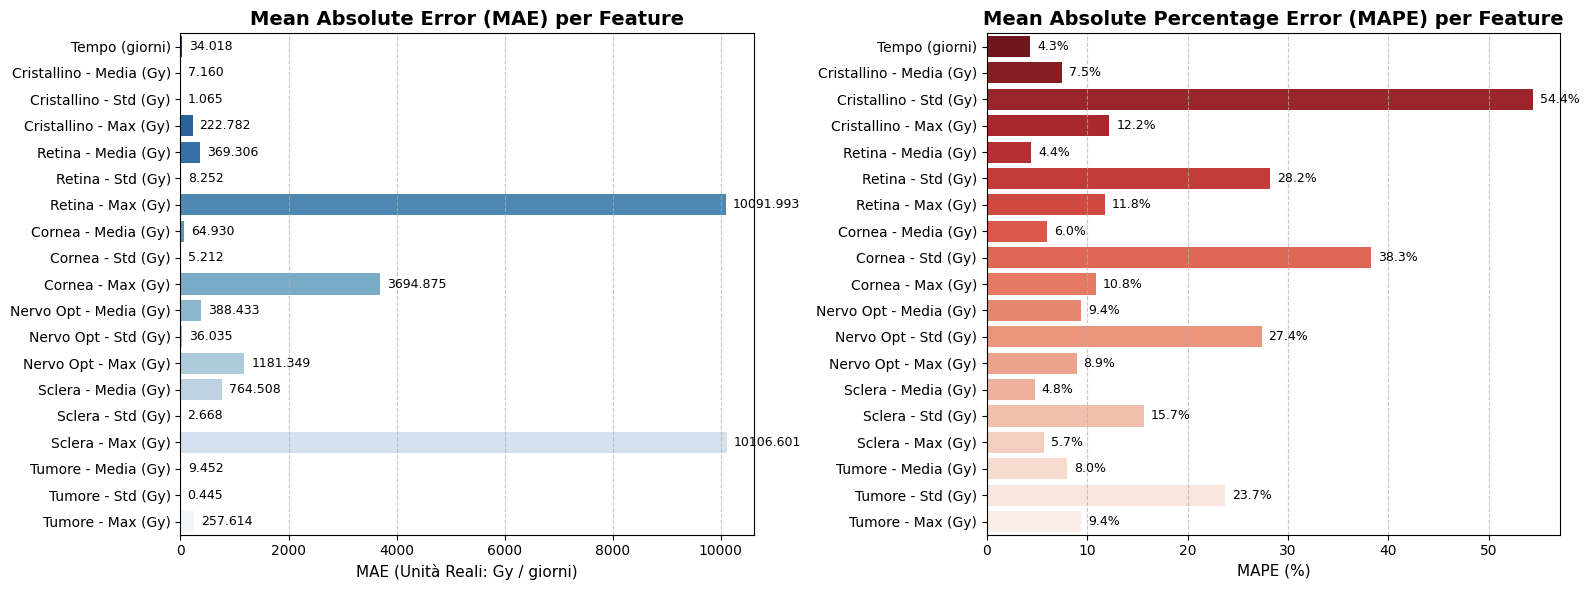

In [ ]:
# ==============================================================================
# 1. CALCOLO METRICHE (MAE e MAPE) IN SCALA REALE
# ==============================================================================

# Definiamo le etichette per i 19 output per una lettura immediata
nomi_output = [
    "Tempo (giorni)",
    "Cristallino - Media (Gy)", "Cristallino - Std (Gy)", "Cristallino - Max (Gy)",
    "Retina - Media (Gy)",      "Retina - Std (Gy)",      "Retina - Max (Gy)",
    "Cornea - Media (Gy)",      "Cornea - Std (Gy)",      "Cornea - Max (Gy)",
    "Nervo Opt - Media (Gy)",   "Nervo Opt - Std (Gy)",   "Nervo Opt - Max (Gy)",
    "Sclera - Media (Gy)",      "Sclera - Std (Gy)",      "Sclera - Max (Gy)",
    "Tumore - Media (Gy)",      "Tumore - Std (Gy)",      "Tumore - Max (Gy)"
]

# Calcolo MAE e MAPE globale e per feature
mae_per_feature = mean_absolute_error(y_test_reale, test_pred_reale, multioutput='raw_values')
mape_per_feature = mean_absolute_percentage_error(y_test_reale, test_pred_reale, multioutput='raw_values') * 100

# Creazione di un DataFrame riassuntivo
df_metriche = pd.DataFrame({
    'Feature': nomi_output,
    'MAE': mae_per_feature,
    'MAPE (%)': mape_per_feature
})

# Stampa tabella in console
print("="*65)
print("              TABELLA VALUTAZIONE METRICHE TEST SET             ")
print("="*65)
print(df_metriche.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*65)
print(f"MAE Medio Globale:  {np.mean(mae_per_feature):.4f}")
print(f"MAPE Medio Globale: {np.mean(mape_per_feature):.2f}%")
print("="*65)


# ==============================================================================
# 2. GRAFICI A BARRE PER MAE E MAPE
# ==============================================================================

plt.figure(figsize=(16, 6))

# --- Grafico 1: MAE ---
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=df_metriche, x='MAE', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Mean Absolute Error (MAE) per Feature', fontsize=14, fontweight='bold')
plt.xlabel('MAE (Unità Reali: Gy / giorni)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Aggiunge i valori sulle barre
for p in ax1.patches:
    width = p.get_width()
    ax1.annotate(f'{width:.3f}', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

# --- Grafico 2: MAPE ---
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=df_metriche, x='MAPE (%)', y='Feature', hue='Feature', palette='Reds_r', legend=False)
plt.title('Mean Absolute Percentage Error (MAPE) per Feature', fontsize=14, fontweight='bold')
plt.xlabel('MAPE (%)', fontsize=11)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Aggiunge i valori sulle barre
for p in ax2.patches:
    width = p.get_width()
    ax2.annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

## 1.5 Diagnostica dell'Addestramento: Curve di Learning e Valutazione dell'Overfitting (Scala Lineare e Logaritmica)

In questa sezione viene effettuata l'analisi diagnostica della dinamica di apprendimento del modello surrogato ($f_\theta$) lungo le $500$ epoche di addestramento, confrontando le curve di **Training Loss** e **Validation Loss** sia in scala lineare che in scala logaritmica.

---

### Visualizzazione Doppia: Lineare vs Logaritmica

L'utilizzo combinato dei due grafici consente un'ispezione approfondita della fase di ottimizzazione:

1. **Grafico in Scala Lineare:**
   * Fornisce un'immediata percezione visiva dell'imponente crollo iniziale della loss nelle prime epoche.
   * Evidenzia la stabilità della convergenza al raggiungimento del minimo e mostra chiaramente l'impatto delle riduzioni del Learning Rate apportate dallo scheduler `ReduceLROnPlateau`.

2. **Grafico in Scala Logaritmica (`plt.yscale('log')`):**
   * **Risoluzione sui Piccoli Ordini di Grandezza:** Comprime i grandi valori iniziali e amplifica i dettagli delle fasi avanzate dell'addestramento, dove le variazioni di loss diventano dell'ordine di $10^{-3}$ o $10^{-4}$.
   * **Diagnostica di Precisione sull'Overfitting:** Permette di monitorare con estrema sensibilità il divario (*generalization gap*) tra Training e Validation Loss nelle ultime centinaia di epoche, confermando che la curva di validazione rimanga piatta o decrescente anziché divergere verso l'alto.

---

### Identificazione del Checkpoint Ottimale

In entrambi i grafici, il punto rosso evidenzia l'epoca esatta ($\text{argmin}(\text{Val Loss})$) in cui la rete ha ottenuto il minimo assoluto della funzione di costo sui dati di validazione. Questo punto corrisponde allo stato dei pesi salvato su disco (`checkpoint_migliore.pth`), garantendo l'impiego della miglior versione possibile del modello per i Task successivi.

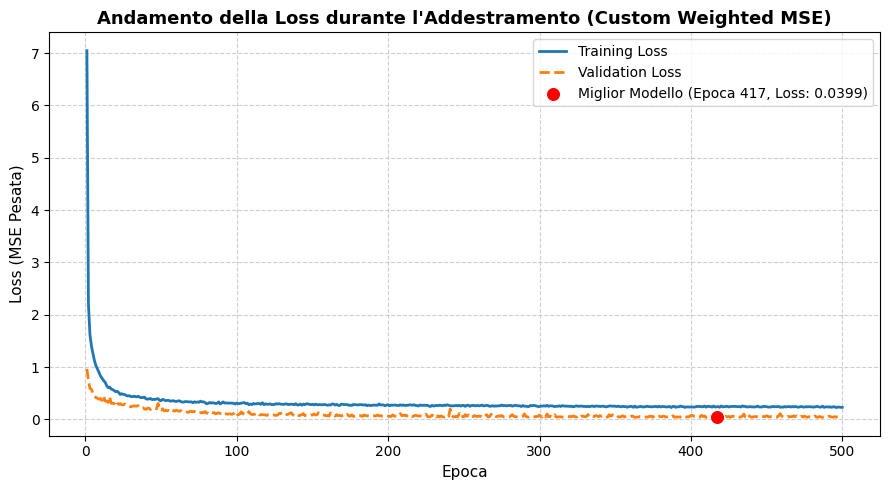

In [ ]:
# ==============================================================================
# GRAFICO CURVA DI LEARNING (TRAIN VS VALIDATION LOSS)
# ==============================================================================
plt.figure(figsize=(9, 5))

epoche = range(1, len(train_losses) + 1)

# Plot delle curve
plt.plot(epoche, train_losses, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(epoche, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')

# Evidenziamo l'epoca con la miglior validation loss (checkpoint salvato)
best_epoch = np.argmin(val_losses) + 1
min_val_loss = min(val_losses)
plt.scatter(best_epoch, min_val_loss, color='red', s=70, zorder=5,
            label=f'Miglior Modello (Epoca {best_epoch}, Loss: {min_val_loss:.4f})')

# Formattazione e stile grafico
plt.title('Andamento della Loss durante l\'Addestramento (Custom Weighted MSE)', fontsize=13, fontweight='bold')
plt.xlabel('Epoca', fontsize=11)
plt.ylabel('Loss (MSE Pesata)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('learning_curve_loss.png', dpi=300)
plt.show()

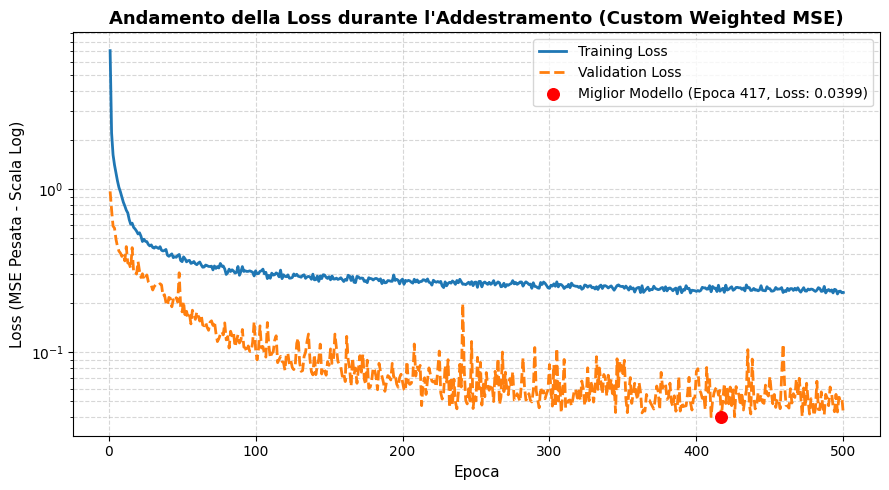

In [ ]:
# ==============================================================================
# GRAFICO CURVA DI LEARNING (TRAIN VS VALIDATION LOSS) - SCALA LOGARITMICA
# ==============================================================================
plt.figure(figsize=(9, 5))

epoche = range(1, len(train_losses) + 1)

# Plot delle curve
plt.plot(epoche, train_losses, label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(epoche, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')

# Evidenziamo l'epoca con la miglior validation loss (checkpoint salvato)
best_epoch = np.argmin(val_losses) + 1
min_val_loss = min(val_losses)
plt.scatter(best_epoch, min_val_loss, color='red', s=70, zorder=5,
            label=f'Miglior Modello (Epoca {best_epoch}, Loss: {min_val_loss:.4f})')

# Impostazione scala logaritmica sull'asse Y
plt.yscale('log')

# Formattazione e stile grafico
plt.title('Andamento della Loss durante l\'Addestramento (Custom Weighted MSE)', fontsize=13, fontweight='bold')
plt.xlabel('Epoca', fontsize=11)
plt.ylabel('Loss (MSE Pesata - Scala Log)', fontsize=11)

# 'which="both"' mostra la griglia sia per i tick principali che secondari della scala log
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('learning_curve_loss.png', dpi=300)
plt.show()

In [ ]:
# =====================================================================================
#     STAMPA DEI RISULTATI COMPLETI
# =====================================================================================
print("\n" + "="*85)
print("     RISULTATI COMPLETI SUL TEST SET (Tutte le Simulazioni)")
print("="*85)

organi = ["Cristallino", "Retina", "Cornea", "Nervo Ottico", "Sclera", "Tumore"]
num_test_sims = len(y_test_reale)

for j in range(num_test_sims):
    sin_t = X_test[j][0]
    cos_t = X_test[j][1]
    angolo_rad = np.arctan2(sin_t, cos_t)
    angolo_deg = round((np.degrees(angolo_rad) + 360) % 360)

    print(f"\n--- Previsione per la Simulazione {j+1} (Angolo Placca: {angolo_deg}°) ---")

    tempo_vero = y_test_reale[j][0]
    tempo_pred = max(0.0, test_pred_reale[j][0])

    print(f"{'TEMPO (giorni)':<15} | VERO: {tempo_vero:.4f}  |  PREDETTO: {tempo_pred:.4f}")
    print("-" * 85)

    print(f"{'ORGANO':<14} | {'DOSE MEDIA VERA':<17} | {'DOSE MEDIA PRED':<17} | {'DOSE MAX VERA':<15} | {'DOSE MAX PRED'}")
    print("-" * 85)

    for i, organo in enumerate(organi):
        idx_media = 1 + (i * 3)
        idx_max   = 1 + (i * 3) + 2

        media_vera = y_test_reale[j][idx_media]
        media_pred = max(0.0, test_pred_reale[j][idx_media])
        media_std  = test_pred_std[j][idx_media] # Incertezza sulla media

        max_vera = y_test_reale[j][idx_max]
        max_pred = max(0.0, test_pred_reale[j][idx_max])
        max_std  = test_pred_std[j][idx_max]     # Incertezza sul massimo
        # Costruiamo la stringa "PRED ± STD" prima di stampare per mantenere l'allineamento perfetto
        str_media_pred = f"{media_pred:.2f} ± {media_std:.2f}"
        str_max_pred = f"{max_pred:.2f} ± {max_std:.2f}"

        print(f"{organo:<14} | {media_vera:<17.2f} | {str_media_pred:<17} | {max_vera:<15.2f} | {str_max_pred}")

    print("-" * 85)


     RISULTATI COMPLETI SUL TEST SET (Tutte le Simulazioni)

--- Previsione per la Simulazione 1 (Angolo Placca: 260°) ---
TEMPO (giorni)  | VERO: 1401.4546  |  PREDETTO: 1394.0781
-------------------------------------------------------------------------------------
ORGANO         | DOSE MEDIA VERA   | DOSE MEDIA PRED   | DOSE MAX VERA   | DOSE MAX PRED
-------------------------------------------------------------------------------------
Cristallino    | 216.97            | 205.22 ± 38.44    | 4021.91         | 3669.15 ± 763.61
Retina         | 14808.55          | 14819.92 ± 3434.80 | 280192.66       | 258553.09 ± 82204.47
Cornea         | 1796.54           | 1795.30 ± 367.53  | 64306.22        | 60609.02 ± 11105.21
Nervo Ottico   | 4155.83           | 4349.07 ± 873.98  | 9617.19         | 8439.52 ± 1534.46
Sclera         | 29465.28          | 29205.96 ± 6925.34 | 519911.00       | 490590.72 ± 117268.15
Tumore         | 154.85            | 179.85 ± 26.18    | 4221.40         | 5270.55

## 1.6 Valutazione Grafica delle Prestazioni: Scatter Plot e Incertezza Epistemica (MC Dropout)

In questa sezione completiamo la diagnostica del **Task 1** attraverso un'ispezione visiva approfondita delle predizioni fornite dal modello surrogato ($f_\theta$) rispetto ai dati reali del **Test Set**.

---

### Diagnostica Visiva mediante Scatter Plot e Incertezza Epistemica

Per valutare la bontà e la stabilità delle predizioni sulle 19 variabili di output, vengono generati tre grafici riassuntivi basati su **Scatter Plot con Barre d'Errore**:

1. **Tempo di Trattamento (Giorni):** Confronto diretto tra la durata reale simulata e quella predetta dal modello surrogato.
2. **Dose Media negli Organi a Rischio e nel Tumore (Gy):** Una griglia $2 \times 3$ che illustra la stima della dose media depositata su Cristallino, Retina, Cornea, Nervo Ottico, Sclera e Tumore.
3. **Dose Massima / Hotspot (Gy):** Una griglia $2 \times 3$ focalizzata sulla previsione dei picchi di dose massima negli OAR e nel tumore.

---

### Dettagli Metodologici dei Grafici

* **Bisettrice ($y = x$):** La retta tratteggiata rossa (o nera) rappresenta la condizione di **previsione perfetta**. L'addensamento stretto e uniforme dei punti lungo questa diagonale attesta un'elevata accuratezza del modello su tutto l'intervallo dinamico dei dati.
* **Barre d'Errore (Incertezza Epistemica $\sigma_{\text{MC}}$):** Ciascun punto riporta una barra d'errore verticale derivata dalle $100$ simulazioni stocastiche di Monte Carlo Dropout.
  * Un'ampiezza ridotta delle barre indica che la rete ha una **forte confidenza** nella predizione.
  * Barre più ampie evidenziano regioni dello spazio delle configurazioni in cui l'incertezza del modello è maggiore.

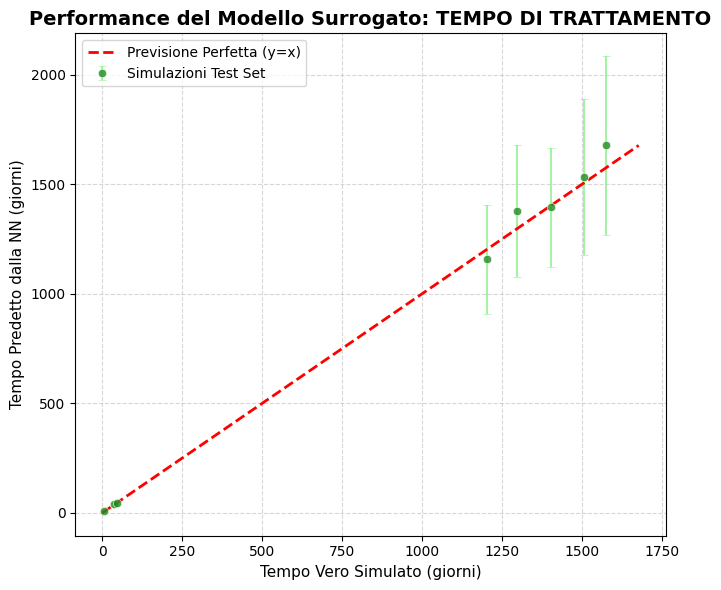

In [ ]:
# ==========================================
# GRAFICO 3: TEMPO DI TRATTAMENTO (GIORNI)
# ==========================================
plt.figure(figsize=(7, 6))

tempo_vero = y_test_reale[:, 0]
tempo_predetto = test_pred_reale[:, 0]
tempo_std = test_pred_std[:, 0]

# Scatter plot con barre d'errore (Incertezza Epistemica)
plt.errorbar(tempo_vero, tempo_predetto, yerr=tempo_std,
             fmt='o', color='forestgreen', ecolor='lightgreen', elinewidth=1.5,
             capsize=3, alpha=0.8, markeredgecolor='white', markeredgewidth=0.5,
             label='Simulazioni Test Set')

# Bisettrice (y = x)
min_val = min(0.0, min(tempo_vero.min(), tempo_predetto.min()))
max_val = max(tempo_vero.max(), tempo_predetto.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsione Perfetta (y=x)')

# Formattazione
plt.title("Performance del Modello Surrogato: TEMPO DI TRATTAMENTO", fontsize=14, fontweight='bold')
plt.xlabel('Tempo Vero Simulato (giorni)', fontsize=11)
plt.ylabel('Tempo Predetto dalla NN (giorni)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig('scatter_plot_tempo_test_set.png', dpi=300)


Generazione dei grafici di valutazione del Test Set in corso...
Grafici riassuntivi salvati con successo come 'scatter_plot_media_test_set.png' e 'scatter_plot_max_test_set.png'!


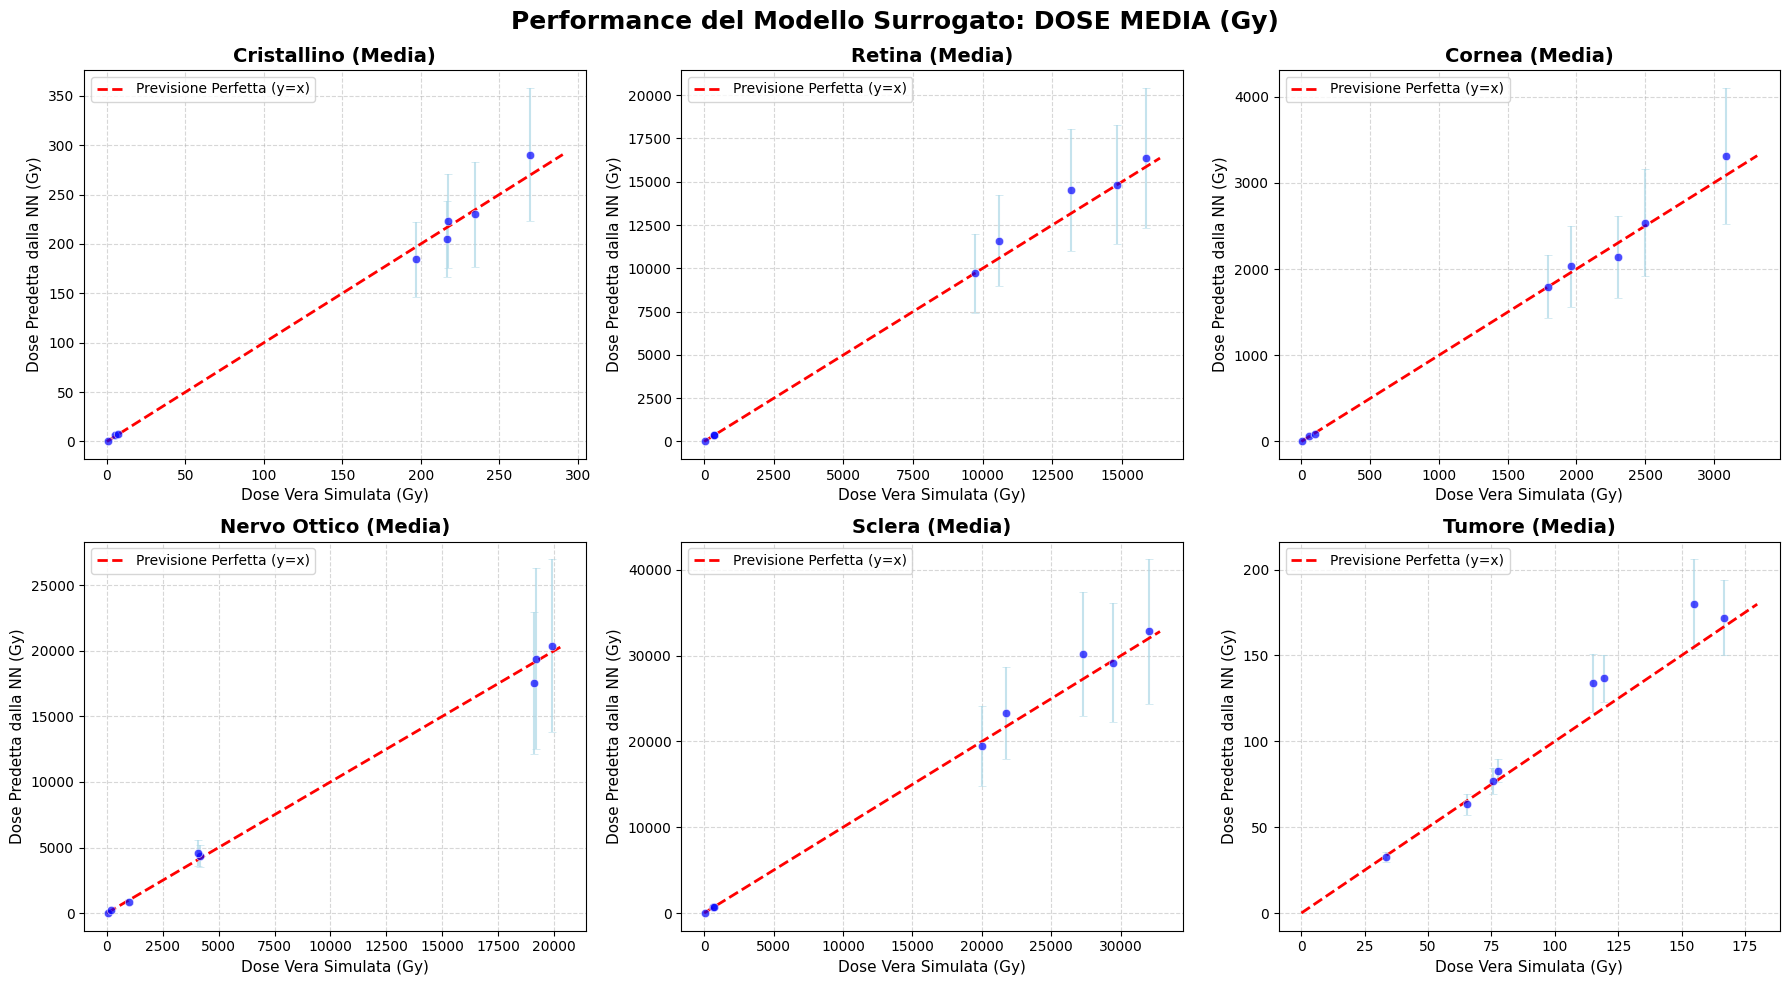

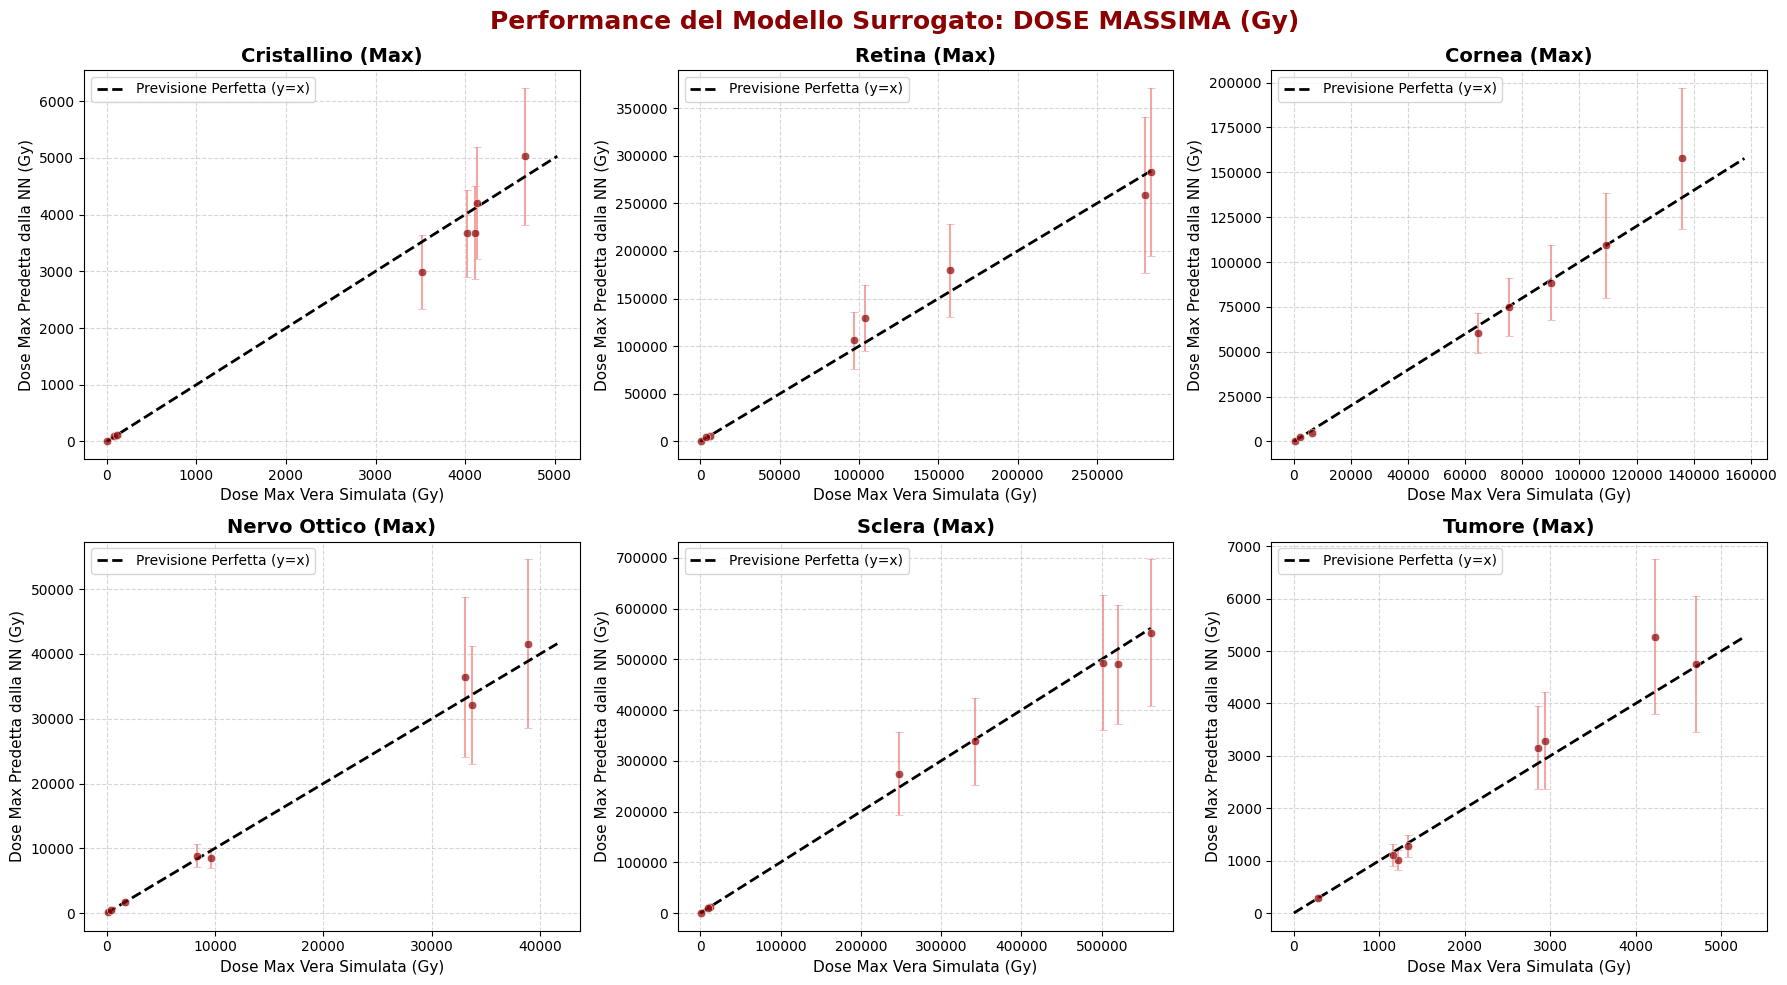

In [ ]:
# Nomi degli organi
organi = ["Cristallino", "Retina", "Cornea", "Nervo Ottico", "Sclera", "Tumore"]

print("\nGenerazione dei grafici di valutazione del Test Set in corso...")

# ==========================================
# GRAFICO 1: DOSE MEDIA
# ==========================================
fig_med, axes_med = plt.subplots(2, 3, figsize=(18, 10))
fig_med.suptitle("Performance del Modello Surrogato: DOSE MEDIA (Gy)", fontsize=18, fontweight='bold')
axes_med = axes_med.flatten()

for i, organo in enumerate(organi):
    # La colonna 0 è il tempo. Ogni organo ha 3 colonne (Media, Std, Max).
    # L'indice della Dose Media è 1 + (i * 3)
    idx_media = 1 + (i * 3)

    dosi_vere = y_test_reale[:, idx_media]
    dosi_predette = test_pred_reale[:, idx_media]

    ax = axes_med[i]

    # Scatter plot
    # Scatter plot con barre d'errore (Incertezza Epistemica)
    ax.errorbar(dosi_vere, dosi_predette, yerr=test_pred_std[:, idx_media],
                fmt='o', color='blue', ecolor='lightblue', elinewidth=1.5,
                capsize=3, alpha=0.7, markeredgecolor='white', markeredgewidth=0.5)

    # Bisettrice (Previsione Perfetta y = x)
    min_val = min(0.0, min(dosi_vere.min(), dosi_predette.min()))
    max_val = max(dosi_vere.max(), dosi_predette.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsione Perfetta (y=x)')

    # Formattazione
    ax.set_title(f'{organo} (Media)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dose Vera Simulata (Gy)', fontsize=11)
    ax.set_ylabel('Dose Predetta dalla NN (Gy)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
fig_med.subplots_adjust(top=0.92) # Lascia spazio per il titolo globale
plt.savefig('scatter_plot_media_test_set.png', dpi=300)

# ==========================================
# GRAFICO 2: DOSE MASSIMA (HOTSPOT)
# ==========================================
fig_max, axes_max = plt.subplots(2, 3, figsize=(18, 10))
fig_max.suptitle("Performance del Modello Surrogato: DOSE MASSIMA (Gy)", fontsize=18, fontweight='bold', color='darkred')
axes_max = axes_max.flatten()

for i, organo in enumerate(organi):
    # L'indice della Dose Massima è 1 + (i * 3) + 2
    idx_max = 1 + (i * 3) + 2

    dosi_vere_max = y_test_reale[:, idx_max]
    dosi_predette_max = test_pred_reale[:, idx_max]

    ax = axes_max[i]

    # Scatter plot (usiamo il rosso per i massimi per distinguerli visivamente)
    # Scatter plot con barre d'errore (Incertezza Epistemica)
    ax.errorbar(dosi_vere_max, dosi_predette_max, yerr=test_pred_std[:, idx_max],
                fmt='o', color='darkred', ecolor='lightcoral', elinewidth=1.5,
                capsize=3, alpha=0.7, markeredgecolor='white', markeredgewidth=0.5)

    # Bisettrice
    min_val = min(0.0, min(dosi_vere_max.min(), dosi_predette_max.min()))
    max_val = max(dosi_vere_max.max(), dosi_predette_max.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Previsione Perfetta (y=x)')

    # Formattazione
    ax.set_title(f'{organo} (Max)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Dose Max Vera Simulata (Gy)', fontsize=11)
    ax.set_ylabel('Dose Max Predetta dalla NN (Gy)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
fig_max.subplots_adjust(top=0.92)
plt.savefig('scatter_plot_max_test_set.png', dpi=300)

print("Grafici riassuntivi salvati con successo come 'scatter_plot_media_test_set.png' e 'scatter_plot_max_test_set.png'!")

# Mostra i grafici a schermo
plt.show()

## Task 2: Ottimizzazione della Posizione della Placca Brachiterapica

In questo Task utilizziamo il modello surrogato $f_\theta$ (addestrato e congelato) come simulatore ad alta velocità per determinare l'angolo di posizionamento della placca ($\theta$) che minimizzi l'esposizione degli Organi a Rischio (OAR) e rispetti tutti i vincoli clinici di sicurezza.

L'ottimizzazione viene eseguita attraverso due approcci complementari:

---

### Task 2A: Ricerca Discreta (Grid Search & Filtering Clinico)

1. **Discretizzazione dello Spazio delle Configurazioni:**
   Sondiamo lo spazio angolare con una griglia discreta di **72 angoli** ($\theta \in [0^\circ, 355^\circ]$ con passo di $5^\circ$), mantenendo fisso l'angolo azimutale $\phi = 0$ e il raggio medio.

2. **Filtro Clinico Vincolante (Hard Constraints):**
   Una posizione è considerata *ammissibile* se e solo se soddisfa contemporaneamente tutti i limiti sulla dose media e sul tempo:
   * $\text{Tempo} < 7.0 \text{ giorni}$
   * $\text{Dose Media Cristallino} < 5.0 \text{ Gy}$
   * $\text{Dose Media Retina} < 45.0 \text{ Gy}$
   * $\text{Dose Media Cornea} < 50.0 \text{ Gy}$
   * $\text{Dose Media Nervo Ottico} < 55.0 \text{ Gy}$
   * $\text{Dose Media Sclera} < 100.0 \text{ Gy}$

3. **Score Adimensionale di Selezione ($S_{\text{max}}$):**
   Tra gli angoli ammissibili, la miglior configurazione viene selezionata minimizzando uno **Score Normalizzato sulle Dosi Massime**:
   $$S_{\text{max}}(\theta) = \sum_{k \in \text{OAR}} \frac{D_{\text{max}, k}(\theta)}{1.5 \cdot L_k}$$
   Dividendo ciascun picco per $1.5 \cdot L_k$ (dove $L_k$ è il limite di dose media), ogni organo contribuisce in modo bilanciato senza che strutture ad altissima dose (es. Sclera) dominino la scelta.

---

### Task 2B: Ottimizzazione Continua Differenziabile (Differentiable Programming Multi-Start)

Mentre la Grid Search (Task 2A) è limitata al passo di $5^\circ$, il **Differentiable Programming** consente di trovare l'ottimo globale nel dominio continuo ($\theta \in \mathbb{R}$) tramite retropropagazione diretta del gradiente sull'input.

1. **Congelamento del Surrogato ($requires\_grad = False$):**
   I pesi della rete neurale vengono bloccati. L'unico parametro ottimizzabile è la variabile geometrica di input $\theta$.

2. **Loss Funzione Clinica Differentiable:**
   Definiamo una funzione di costo composta dallo Score Adimensionale $S_{\text{max}}$ unito a **Penalità Morbide Quadratiche** ($\text{ReLU}^2$) che si attivano solo se le dosi o il tempo superano i limiti di sicurezza:
   $$\mathcal{L}_{\text{clinica}}(\theta) = S_{\text{max}}(\theta) + 1000 \cdot \sum_{k} \left[ \max(0, D_{\text{media}, k}(\theta) - L_k) \right]^2$$

3. **Strategia Multi-Start (Adam Optimizer):**
   Per evitare di rimanere bloccati in minimi locali dovuti alla non-convessità del paesaggio di loss, l'ottimizzazione tramite Adam ($lr=0.05$, $300$ step) viene lanciata da **4 punti di partenza differenti** ($0^\circ, 90^\circ, 180^\circ, 270^\circ$), selezionando infine il valore con la Loss minima globale.

In [ ]:
# ==============================================================================
# TASK 2a: OTTIMIZZAZIONE DELLA POSIZIONE DELLA PLACCA (INFERENCE & FILTERING)
# ==============================================================================
print("\n" + "="*85)
print("   TASK 2: RICERCA DELLA POSIZIONE OTTIMALE (VINCOLI CLINICI)")
print("="*85)

# 1. Spazio di ricerca: 72 angoli da 0° a 355° (passo 5°)
angoli_gradi  = np.arange(0, 360, 5)
angoli_rad    = np.radians(angoli_gradi)
numero_angoli = len(angoli_gradi)

# Feature di input: phi = 0, raggio costante nel dataset (mean == valore di training)
phi_rad      = 0.0
raggio_medio = X[:, 4].mean()

X_opt = np.zeros((numero_angoli, 5))
X_opt[:, 0] = np.sin(angoli_rad)
X_opt[:, 1] = np.cos(angoli_rad)
X_opt[:, 2] = np.sin(phi_rad)
X_opt[:, 3] = np.cos(phi_rad)
X_opt[:, 4] = raggio_medio

# 2. Forward pass deterministico (modello in eval, Dropout disattivo)
X_opt_scaled = scaler_X.transform(X_opt).astype('float32')
X_opt_t      = torch.tensor(X_opt_scaled).to(device)

modello.eval()
with torch.no_grad():
    pred_scaled_opt = modello(X_opt_t).cpu().numpy()

pred_log_opt   = scaler_y.inverse_transform(pred_scaled_opt)
pred_reale_opt = np.expm1(pred_log_opt)

# 3. Metriche per organo
tempo_opt        = pred_reale_opt[:, 0]
crist_media_opt  = pred_reale_opt[:, 1]
retina_media_opt = pred_reale_opt[:, 4]
cornea_media_opt = pred_reale_opt[:, 7]
nervo_media_opt  = pred_reale_opt[:, 10]
sclera_media_opt = pred_reale_opt[:, 13]

crist_max_opt  = pred_reale_opt[:, 3]
retina_max_opt = pred_reale_opt[:, 6]
cornea_max_opt = pred_reale_opt[:, 9]
nervo_max_opt  = pred_reale_opt[:, 12]
sclera_max_opt = pred_reale_opt[:, 15]

# ==============================================================================
# SCORE SULLA DOSE MASSIMA — normalizzato, non pesato
# ==============================================================================
#   Ogni dose max viene divisa per la propria scala L_max = 1.5 * limite clinico.
#   Il risultato è adimensionale: nessun organo domina per scala assoluta e,
#   a parità di "quanto stai riempiendo il tetto", ogni OAR pesa uguale.
#       S(theta) = sum_k  D_max,k(theta) / (1.5 * L_k)
#   Identico allo score usato nel modello a splitting continuo.
# ==============================================================================

LIMITE_MEDIA = {                 # limiti clinici sulla dose MEDIA (Gy)
    'crist':   5.0,
    'retina': 45.0,
    'cornea': 50.0,
    'nervo':  55.0,
    'sclera': 100.0,
}
FATTORE_MAX = 1.5                # scala convenzionale per le dosi massime
LIMITE_MAX  = {k: FATTORE_MAX * v for k, v in LIMITE_MEDIA.items()}

score_max_oar = (
    crist_max_opt  / LIMITE_MAX['crist']  +
    retina_max_opt / LIMITE_MAX['retina'] +
    cornea_max_opt / LIMITE_MAX['cornea'] +
    nervo_max_opt  / LIMITE_MAX['nervo']  +
    sclera_max_opt / LIMITE_MAX['sclera']
)

# 4. Filtro clinico (vincoli hard sulla dose MEDIA)
maschera_vincoli = (
    (tempo_opt        < 7.0)   &
    (crist_media_opt  < 5.0)   &
    (retina_media_opt < 45.0)  &
    (cornea_media_opt < 50.0)  &
    (nervo_media_opt  < 55.0)  &
    (sclera_media_opt < 100.0)
)

angoli_validi = angoli_gradi[maschera_vincoli]


for i, angolo in enumerate(angoli_gradi):
    if not maschera_vincoli[i]:
        motivi = []
        if tempo_opt[i]        >= 7.0:   motivi.append(f"Tempo ({tempo_opt[i]:.2f}gg >= 7)")
        if crist_media_opt[i]  >= 5.0:   motivi.append(f"Cristallino ({crist_media_opt[i]:.2f}Gy >= 5)")
        if retina_media_opt[i] >= 45.0:  motivi.append(f"Retina ({retina_media_opt[i]:.2f}Gy >= 45)")
        if cornea_media_opt[i] >= 50.0:  motivi.append(f"Cornea ({cornea_media_opt[i]:.2f}Gy >= 50)")
        if nervo_media_opt[i]  >= 55.0:  motivi.append(f"Nervo ({nervo_media_opt[i]:.2f}Gy >= 55)")
        if sclera_media_opt[i] >= 100.0: motivi.append(f"Sclera ({sclera_media_opt[i]:.2f}Gy >= 100)")

# 5. Selezione del migliore tra gli angoli validi
if len(angoli_validi) == 0:
    print("\n[!] Nessun angolo soddisfa tutti i limiti clinici.")
else:
    print(f"\n{len(angoli_validi)} angoli rispettano i vincoli clinici.")

    df_validi = pd.DataFrame({
        'Angolo (°)':      angoli_validi,
        'Tempo (gg)':      tempo_opt[maschera_vincoli],
        'Crist. Med (Gy)': crist_media_opt[maschera_vincoli],
        'Retina Med (Gy)': retina_media_opt[maschera_vincoli],
        'Cornea Med (Gy)': cornea_media_opt[maschera_vincoli],
        'Nervo Med (Gy)':  nervo_media_opt[maschera_vincoli],
        'Sclera Med (Gy)': sclera_media_opt[maschera_vincoli],
        'Score Max OAR':   score_max_oar[maschera_vincoli]
    })

    df_ordinato     = df_validi.sort_values(by='Score Max OAR').reset_index(drop=True)
    migliore_angolo = df_ordinato.iloc[0]

    print("\n" + "*"*85)
    print(f"   MIGLIOR CONFIGURAZIONE: {int(migliore_angolo['Angolo (°)'])}°")
    print("*"*85)
    print(f"  Tempo di trattamento    : {migliore_angolo['Tempo (gg)']:.2f} giorni")
    print(f"  Dose Media Cristallino  : {migliore_angolo['Crist. Med (Gy)']:.2f} Gy  (limite: 5 Gy)")
    print(f"  Dose Media Retina       : {migliore_angolo['Retina Med (Gy)']:.2f} Gy  (limite: 45 Gy)")
    print(f"  Dose Media Cornea       : {migliore_angolo['Cornea Med (Gy)']:.2f} Gy  (limite: 50 Gy)")
    print(f"  Dose Media Nervo Ottico : {migliore_angolo['Nervo Med (Gy)']:.2f} Gy  (limite: 55 Gy)")
    print(f"  Dose Media Sclera       : {migliore_angolo['Sclera Med (Gy)']:.2f} Gy  (limite: 100 Gy)")
    print(f"  Score Max OAR           : {migliore_angolo['Score Max OAR']:.3f}")
    print("*"*85)

    print("\nMigliori 14 configurazioni valide (Score Max OAR crescente):")
    print(df_ordinato.head(14).to_string(index=False))



   TASK 2: RICERCA DELLA POSIZIONE OTTIMALE (VINCOLI CLINICI)

9 angoli rispettano i vincoli clinici.

*************************************************************************************
   MIGLIOR CONFIGURAZIONE: 0°
*************************************************************************************
  Tempo di trattamento    : 6.46 giorni
  Dose Media Cristallino  : 0.48 Gy  (limite: 5 Gy)
  Dose Media Retina       : 28.54 Gy  (limite: 45 Gy)
  Dose Media Cornea       : 2.12 Gy  (limite: 50 Gy)
  Dose Media Nervo Ottico : 7.32 Gy  (limite: 55 Gy)
  Dose Media Sclera       : 47.49 Gy  (limite: 100 Gy)
  Score Max OAR           : 10.933
*************************************************************************************

Migliori 14 configurazioni valide (Score Max OAR crescente):
 Angolo (°)  Tempo (gg)  Crist. Med (Gy)  Retina Med (Gy)  Cornea Med (Gy)  Nervo Med (Gy)  Sclera Med (Gy)  Score Max OAR
          0    6.462360         0.481631        28.537775         2.118340       

In [ ]:
# ==============================================================================
# TASK 2b: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING - MULTI START)
# ==============================================================================
import torch
import torch.optim as optim
import numpy as np

print("\n" + "=" * 85)
print("   TASK 2: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING)")
print("=" * 85)

# 1. Congeliamo i pesi del modello surrogato
modello.eval()
for param in modello.parameters():
    param.requires_grad = False

# 2. Parametri clinici e limiti di scala
PHI_RAD = 0.0
RAGGIO_MEDIO = float(X[:, 4].mean())

# Limiti sulla dose MEDIA (Gy) e costante di scala per la dose MAX
LIMITE_MEDIA = {
    'crist':  5.0,
    'retina': 45.0,
    'cornea': 50.0,
    'nervo':  55.0,
    'sclera': 100.0,
}
FATTORE_MAX = 1.5

# Pre-convertiamo medie e scale per PyTorch
mean_X = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
scale_X = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
mean_y = torch.tensor(scaler_y.mean_, dtype=torch.float32, device=device)
scale_y = torch.tensor(scaler_y.scale_, dtype=torch.float32, device=device)


# 3. DEFINIZIONE DELLA LOSS CLINICA (Con Score Normalizzato e Penalità)
def calcola_loss_clinica(pred_reale):
    tempo = pred_reale[0, 0]

    # Dosi Medie per il filtro/penalità
    crist_med  = pred_reale[0, 1]
    retina_med = pred_reale[0, 4]
    cornea_med = pred_reale[0, 7]
    nervo_med  = pred_reale[0, 10]
    sclera_med = pred_reale[0, 13]

    # Score normalizzato adimensionale sulle dosi massime
    score_max_oar = (
        pred_reale[0, 3]  / (FATTORE_MAX * LIMITE_MEDIA['crist'])  +
        pred_reale[0, 6]  / (FATTORE_MAX * LIMITE_MEDIA['retina']) +
        pred_reale[0, 9]  / (FATTORE_MAX * LIMITE_MEDIA['cornea']) +
        pred_reale[0, 12] / (FATTORE_MAX * LIMITE_MEDIA['nervo'])  +
        pred_reale[0, 15] / (FATTORE_MAX * LIMITE_MEDIA['sclera'])
    )

    # Penalità morbide (ReLU quadratico): si attivano solo se si supera la soglia clinica
    penalty_tempo  = torch.relu(tempo - 7.0) ** 2
    penalty_crist  = torch.relu(crist_med - LIMITE_MEDIA['crist']) ** 2
    penalty_retina = torch.relu(retina_med - LIMITE_MEDIA['retina']) ** 2
    penalty_cornea = torch.relu(cornea_med - LIMITE_MEDIA['cornea']) ** 2
    penalty_nervo  = torch.relu(nervo_med - LIMITE_MEDIA['nervo']) ** 2
    penalty_sclera = torch.relu(sclera_med - LIMITE_MEDIA['sclera']) ** 2

    # Loss totale: Minimizzo lo Score adimensionale + Penalizzo pesantemente le violazioni
    loss_totale = (
        score_max_oar
        + 1000.0 * (
            penalty_tempo
            + penalty_crist
            + penalty_retina
            + penalty_cornea
            + penalty_nervo
            + penalty_sclera
        )
    )

    return loss_totale, score_max_oar


# --- INIZIO MULTI-START OPTIMIZATION ---
punti_partenza_deg = [0.0, 90.0, 180.0, 270.0]
miglior_loss_assoluta = float('inf')
ottimo_assoluto_deg = None
predizioni_ottime = None

print("Inizio ottimizzazione differenziabile multi-start...")

for start_deg in punti_partenza_deg:
    # Definiamo l'angolo theta di partenza
    theta_param = torch.tensor(
        [np.radians(start_deg)],
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )
    optimizer_plaque = optim.Adam([theta_param], lr=0.05)

    num_steps = 300
    for step in range(num_steps):
        optimizer_plaque.zero_grad()

        # Ricostruzione differenziabile del vettore di input x
        sin_t = torch.sin(theta_param)
        cos_t = torch.cos(theta_param)
        sin_p = torch.tensor([np.sin(PHI_RAD)], dtype=torch.float32, device=device)
        cos_p = torch.tensor([np.cos(PHI_RAD)], dtype=torch.float32, device=device)
        r_val = torch.tensor([RAGGIO_MEDIO], dtype=torch.float32, device=device)

        x_input = torch.cat([sin_t, cos_t, sin_p, cos_p, r_val]).unsqueeze(0).float()
        x_input_scaled = (x_input - mean_X) / scale_X

        # Forward pass attraverso il modello surrogato
        pred_scaled = modello(x_input_scaled)
        pred_log = (pred_scaled * scale_y) + mean_y
        pred_reale = torch.expm1(pred_log)

        loss, score_max = calcola_loss_clinica(pred_reale)
        loss.backward()
        optimizer_plaque.step()

    loss_finale = loss.item()
    angolo_trovato = (np.degrees(theta_param.item()) % 360 + 360) % 360

    print(
        f"  └ Start da {start_deg:3.0f}° ➔ Angolo Trovato: {angolo_trovato:6.2f}° | Loss Final: {loss_finale:.4f}"
    )

    if loss_finale < miglior_loss_assoluta:
        miglior_loss_assoluta = loss_finale
        ottimo_assoluto_deg = angolo_trovato
        predizioni_ottime = pred_reale.detach().cpu().numpy()

# 6. Risultato Finale
print("\n" + "*" * 85)
print(
    f" MIGLIOR ANGOLO GLOBALE TROVATO (MULTI-START): {ottimo_assoluto_deg:.2f}°"
)
print(f"    Loss Clinica Totale: {miglior_loss_assoluta:.4f}")

# Stampa delle metriche nella posizione ottimale trovata
print("\n[ METRICHE CLINICHE PREDETTE ALL'ANGOLO OTTIMALE ]")
print(f"Tempo di trattamento   : {predizioni_ottime[0, 0]:.2f} giorni")
print(f"Dose Media Cristallino : {predizioni_ottime[0, 1]:.2f} Gy (limite: 5 Gy)")
print(f"Dose Media Retina      : {predizioni_ottime[0, 4]:.2f} Gy (limite: 45 Gy)")
print(f"Dose Media Cornea      : {predizioni_ottime[0, 7]:.2f} Gy (limite: 50 Gy)")
print(f"Dose Media Nervo Ott.  : {predizioni_ottime[0, 10]:.2f} Gy (limite: 55 Gy)")
print(f"Dose Media Sclera      : {predizioni_ottime[0, 13]:.2f} Gy (limite: 100 Gy)")
print("*" * 85)


   TASK 2: OTTIMIZZAZIONE POSIZIONE PLACCA (DIFFERENTIABLE PROGRAMMING)
Inizio ottimizzazione differenziabile multi-start...
  └ Start da   0° ➔ Angolo Trovato: 359.79° | Loss Final: 10.9304
  └ Start da  90° ➔ Angolo Trovato:  55.22° | Loss Final: 49240000.0000
  └ Start da 180° ➔ Angolo Trovato: 180.44° | Loss Final: 670046027776.0000
  └ Start da 270° ➔ Angolo Trovato: 309.53° | Loss Final: 47299872.0000

*************************************************************************************
 MIGLIOR ANGOLO GLOBALE TROVATO (MULTI-START): 359.79°
    Loss Clinica Totale: 10.9304

[ METRICHE CLINICHE PREDETTE ALL'ANGOLO OTTIMALE ]
Tempo di trattamento   : 6.47 giorni
Dose Media Cristallino : 0.48 Gy (limite: 5 Gy)
Dose Media Retina      : 28.56 Gy (limite: 45 Gy)
Dose Media Cornea      : 2.11 Gy (limite: 50 Gy)
Dose Media Nervo Ott.  : 7.21 Gy (limite: 55 Gy)
Dose Media Sclera      : 47.50 Gy (limite: 100 Gy)
*****************************************************************************

## Task 3: Analisi di Robustezza e Stima della Zona d'Incertezza dell'Angolo Ottimale (Monte Carlo Dropout)

Nella pianificazione clinica reale della brachiterapia oculare, la soluzione ottimale deterministica individuata nei Task precedenti può essere soggetta a fluttuazioni dovute alle incertezze del modello o alle tolleranze meccanico-chirurgiche di posizionamento della placca.

Nel **Task 3** quantifichiamo la **robustezza e la stabilità** dell'angolo ottimale sfruttando il **Monte Carlo Dropout** in due modalità complementari:

---

### Task 3A: Valutazione della Frequenza Discreta su Grande Scala (10.000 Iterazioni)

1. **Iniezione Stocastica dell'Incertezza del Modello:**
   Mantenendo la rete neurale in modalità `modello.train()`, ad ogni iterazione una sotto-rete differente (con il $15\%$ dei neuroni disattivati casualmente) valuta l'intero grigliato discreto di 72 angoli ($\theta \in [0^\circ, 355^\circ]$).

2. **Campionamento del Vincitore Statistico:**
   Per ciascuna delle $10.000$ iterazioni, la rete estrae l'angolo discreto che rispetta i vincoli clinici e minimizza lo Score Adimensionale $S_{\text{max}}$.
   
3. **Distribuzione delle Frequenze:**
   Contando quante volte un determinato angolo risulta il migliore, si ottiene la **percentuale di confidenza clinica** sulla scelta della configurazione discreta più robusta.

---

### Task 3B: Stima della Densità di Probabilità Continua dell'Angolo Ottimale (Differentiable MC Dropout)

Mentre il Task 3A lavora sulla griglia discreta ($5^\circ$), il Task 3B analizza la **distribuzione di probabilità continua dell'angolo ottimale** $\theta^*$ mediante ottimizzazione basata su gradiente:

1. **Multi-Run Gradient Descent con Dropout Attivo:**
   Si eseguono $1.000$ ottimizzazioni differenziabili indipendenti ($150$ step di Adam per run). Ad ogni run, la retropropagazione avviene attraverso una differente maschera di dropout, simulando la risposta di un ensemble stocastico nello spazio continuo.

2. **Gestione della Continuità al Bordo (Trattamento della Discontinuità $0^\circ / 360^\circ$):**
   Poiché la zona ottimale si trova in prossimità del bordo $0^\circ \equiv 360^\circ$, gli angoli prossimi a $360^\circ$ (es. $359.8^\circ$) vengono mappati negativamente (es. $-0.2^\circ$). Questo passaggio previene artefatti nella stima della media e della deviazione standard.

3. **Incertezza Clinica e Intervallo di Confidenza al 95%:**
   Vengono calcolate la media ($\mu_{\theta^*}$) e la deviazione standard ($\sigma_{\theta^*}$). L'intervallo di confidenza al $95\%$ ($\mu \pm 1.96 \sigma$) definisce la **Zona d'Incertezza Posizionale Clinica**, rappresentata graficamente tramite stima della densità di probabilità Kernel Density Estimation (KDE) e istogramma.

In [ ]:
# ==============================================================================
# TASK 3 a: OTTIMIZZAZIONE ROBUSTA TRAMITE MONTE CARLO DROPOUT (10000 ITERAZIONI)
# ==============================================================================
print("\n" + "=" * 85)
print("   TASK 3: OTTIMIZZAZIONE ROBUSTA (10000 ITERAZIONI)")
print("=" * 85)

n_iterazioni = 10000
migliori_angoli_storico = []

# 1. Limiti clinici per la normalizzazione dello score
LIMITE_MEDIA = {
    'crist': 5.0,
    'retina': 45.0,
    'cornea': 50.0,
    'nervo': 55.0,
    'sclera': 100.0,
}
FATTORE_MAX = 1.5
LIMITE_MAX = {k: FATTORE_MAX * v for k, v in LIMITE_MEDIA.items()}

# 2. Creazione dello Spazio di Ricerca Fisso
angoli_gradi = np.arange(0, 360, 5)
numero_angoli = len(angoli_gradi)
angoli_rad = np.radians(angoli_gradi)
phi_rad = 0.0
raggio_medio = X[:, 4].mean()

X_opt = np.zeros((numero_angoli, 5))
X_opt[:, 0] = np.sin(angoli_rad)
X_opt[:, 1] = np.cos(angoli_rad)
X_opt[:, 2] = np.sin(phi_rad)
X_opt[:, 3] = np.cos(phi_rad)
X_opt[:, 4] = raggio_medio

X_opt_scaled = scaler_X.transform(X_opt).astype('float32')
X_opt_t = torch.tensor(X_opt_scaled).to(device)

# Manteniamo attivo il Dropout per campionare l'incertezza!
modello.train()

print(
    f"Esecuzione di {n_iterazioni} simulazioni Monte Carlo per trovare l'ottimo robusto..."
)

# 3. Simulazioni Monte Carlo
for i in range(n_iterazioni):
    with torch.no_grad():
        # Ad ogni passaggio il dropout disattiva neuroni diversi
        pred_scaled_opt = modello(X_opt_t).cpu().numpy()

    pred_log_opt = scaler_y.inverse_transform(pred_scaled_opt)
    pred_reale_opt = np.expm1(pred_log_opt)

    # Estrazione Dosi Medie per il filtro
    tempo_opt = pred_reale_opt[:, 0]
    crist_media_opt = pred_reale_opt[:, 1]
    retina_media_opt = pred_reale_opt[:, 4]
    cornea_media_opt = pred_reale_opt[:, 7]
    nervo_media_opt = pred_reale_opt[:, 10]
    sclera_media_opt = pred_reale_opt[:, 13]

    # Estrazione Dosi Max per lo Score Normalizzato
    crist_max_opt = pred_reale_opt[:, 3]
    retina_max_opt = pred_reale_opt[:, 6]
    cornea_max_opt = pred_reale_opt[:, 9]
    nervo_max_opt = pred_reale_opt[:, 12]
    sclera_max_opt = pred_reale_opt[:, 15]

    # SCORE NORMALIZED ADIMENSIONALE
    score_max_oar = (
        crist_max_opt / LIMITE_MAX['crist']
        + retina_max_opt / LIMITE_MAX['retina']
        + cornea_max_opt / LIMITE_MAX['cornea']
        + nervo_max_opt / LIMITE_MAX['nervo']
        + sclera_max_opt / LIMITE_MAX['sclera']
    )

    # Applicazione dei Vincoli Clinici sulla dose MEDIA
    maschera_vincoli = (
        (tempo_opt < 7.0)
        & (crist_media_opt < LIMITE_MEDIA['crist'])
        & (retina_media_opt < LIMITE_MEDIA['retina'])
        & (cornea_media_opt < LIMITE_MEDIA['cornea'])
        & (nervo_media_opt < LIMITE_MEDIA['nervo'])
        & (sclera_media_opt < LIMITE_MEDIA['sclera'])
    )

    angoli_validi = angoli_gradi[maschera_vincoli]
    score_valido = score_max_oar[maschera_vincoli]

    # Se c'è almeno un angolo valido in questa specifica iterazione
    if len(angoli_validi) > 0:
        # Trova l'angolo con il MINOR SCORE ADIMENSIONALE
        idx_migliore = np.argmin(score_valido)
        miglior_angolo_iterazione = angoli_validi[idx_migliore]
        migliori_angoli_storico.append(miglior_angolo_iterazione)

# 4. Analisi Statistica dei Risultati
conteggio_angoli = collections.Counter(migliori_angoli_storico)

print("\n" + "-" * 85)
print(f" RISULTATI FREQUENZA (Su {n_iterazioni} iterazioni)")
print("-" * 85)

if len(conteggio_angoli) == 0:
    print(
        f"Nessun angolo ha superato i vincoli nelle {n_iterazioni} iterazioni."
    )
else:
    for angolo, conteggio in conteggio_angoli.most_common():
        percentuale = (conteggio / n_iterazioni) * 100
        print(
            f"Angolo {angolo:3d}° è risultato il MIGLIORE {conteggio:4d} volte ({percentuale:5.1f}%)"
        )

    angolo_assoluto = conteggio_angoli.most_common(1)[0][0]
    confidenza = (conteggio_angoli.most_common(1)[0][1] / n_iterazioni) * 100

    print("\n" + "*" * 85)
    print(
        f"   VINCITORE STATISTICO: L'angolo più robusto è {angolo_assoluto}°"
    )
    print(f"   Confidenza del modello: {confidenza:.1f}%")
    print("*" * 85)


   TASK 3: OTTIMIZZAZIONE ROBUSTA (10000 ITERAZIONI)
Esecuzione di 10000 simulazioni Monte Carlo per trovare l'ottimo robusto...

-------------------------------------------------------------------------------------
 RISULTATI FREQUENZA (Su 10000 iterazioni)
-------------------------------------------------------------------------------------
Angolo   0° è risultato il MIGLIORE 3322 volte ( 33.2%)
Angolo   5° è risultato il MIGLIORE 2434 volte ( 24.3%)
Angolo 355° è risultato il MIGLIORE 2255 volte ( 22.6%)
Angolo  10° è risultato il MIGLIORE  921 volte (  9.2%)
Angolo 350° è risultato il MIGLIORE  623 volte (  6.2%)
Angolo  15° è risultato il MIGLIORE  248 volte (  2.5%)
Angolo 345° è risultato il MIGLIORE  106 volte (  1.1%)
Angolo  20° è risultato il MIGLIORE   41 volte (  0.4%)
Angolo 340° è risultato il MIGLIORE   26 volte (  0.3%)
Angolo  25° è risultato il MIGLIORE   10 volte (  0.1%)
Angolo 335° è risultato il MIGLIORE    7 volte (  0.1%)
Angolo 330° è risultato il MIGLIORE   


   TASK 3: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT DESCENT)
Esecuzione di 1000 ottimizzazioni via Gradient Descent con perturbazioni MC Dropout...
  └ Run [ 50/1000] completata...
  └ Run [100/1000] completata...
  └ Run [150/1000] completata...
  └ Run [200/1000] completata...
  └ Run [250/1000] completata...
  └ Run [300/1000] completata...
  └ Run [350/1000] completata...
  └ Run [400/1000] completata...
  └ Run [450/1000] completata...
  └ Run [500/1000] completata...
  └ Run [550/1000] completata...
  └ Run [600/1000] completata...
  └ Run [650/1000] completata...
  └ Run [700/1000] completata...
  └ Run [750/1000] completata...
  └ Run [800/1000] completata...
  └ Run [850/1000] completata...
  └ Run [900/1000] completata...
  └ Run [950/1000] completata...
  └ Run [1000/1000] completata...

*************************************************************************************
 RISULTATI DELL'OTTIMIZZAZIONE PROBABILISTICA CONTINUA
******************************

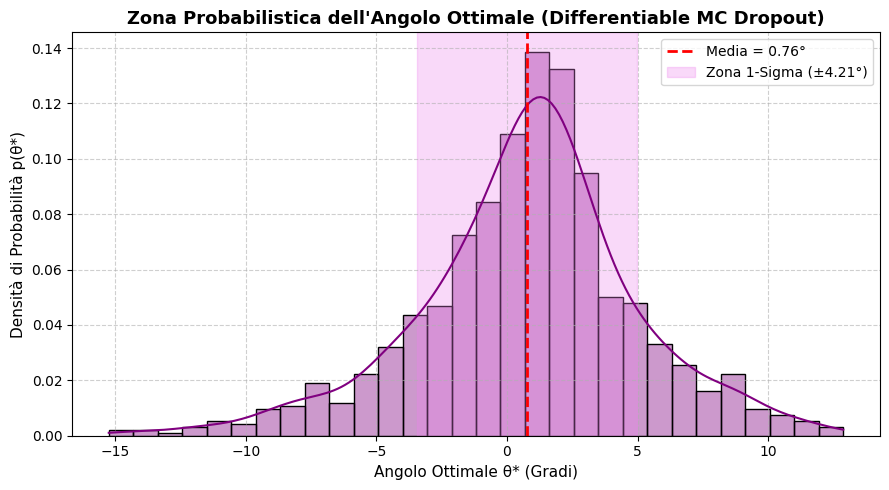

In [ ]:
# ==============================================================================
# TASK 3 b: OTTIMIZZAZIONE ROBUSTA DIFFERENTIABILE (ZONA PROBABILISTICA VIA MC DROPOUT)
# ==============================================================================
print("\n" + "=" * 85)
print(
    "   TASK 3: ESTIMATING PROBABILISTIC CONTINUOUS OPTIMAL ZONE (GRADIENT"
    " DESCENT)"
)
print("=" * 85)

n_runs_mc = 1000  # Numero di ottimizzazioni differenziabili indipendenti
angoli_ottimi_continui = []
losses_ottime = []

# Congeliamo i pesi della rete, MA teniamo il Dropout attivo!
for param in modello.parameters():
  param.requires_grad = False

# ATTENZIONE: modello.train() garantisce che il Dropout sia attivo durante la backprop!
modello.train()

# Parametri fisici costanti
PHI_RAD = 0.0
RAGGIO_MEDIO = float(X[:, 4].mean())

mean_X = torch.tensor(scaler_X.mean_, dtype=torch.float32, device=device)
scale_X = torch.tensor(scaler_X.scale_, dtype=torch.float32, device=device)
mean_y = torch.tensor(scaler_y.mean_, dtype=torch.float32, device=device)
scale_y = torch.tensor(scaler_y.scale_, dtype=torch.float32, device=device)

print(
    f"Esecuzione di {n_runs_mc} ottimizzazioni via Gradient Descent con"
    " perturbazioni MC Dropout..."
)

for run in range(n_runs_mc):
  # Inizializziamo ogni run in prossimità della zona promettente (0° / 360°) - LOGICA ORIGINALE
  theta_param = torch.tensor(
      [np.radians(0.0)], dtype=torch.float32, device=device, requires_grad=True
  )
  optimizer_plaque = optim.Adam([theta_param], lr=0.03)

  # Breve ciclo di gradient descent per convergere sotto la maschera di dropout corrente
  for step in range(150):
    optimizer_plaque.zero_grad()

    sin_t, cos_t = torch.sin(theta_param), torch.cos(theta_param)
    sin_p = torch.tensor([np.sin(PHI_RAD)], dtype=torch.float32, device=device)
    cos_p = torch.tensor([np.cos(PHI_RAD)], dtype=torch.float32, device=device)
    r_val = torch.tensor([RAGGIO_MEDIO], dtype=torch.float32, device=device)

    x_input = (
        torch.cat([sin_t, cos_t, sin_p, cos_p, r_val]).unsqueeze(0).float()
    )
    x_input_scaled = (x_input - mean_X) / scale_X

    # Forward pass con Dropout attivo
    pred_scaled = modello(x_input_scaled)
    pred_log = (pred_scaled * scale_y) + mean_y
    pred_reale = torch.expm1(pred_log)

    loss, _ = calcola_loss_clinica(pred_reale)
    loss.backward()
    optimizer_plaque.step()

  # Salviamo l'angolo finale in gradi [0, 360)
  ang_deg = (np.degrees(theta_param.item()) % 360 + 360) % 360

  # Se l'angolo è vicinissimo a 360 (es. 359.8°), lo mappiamo a valori attorno allo 0 per continuità
  if ang_deg > 180:
    ang_deg = ang_deg - 360.0

  angoli_ottimi_continui.append(ang_deg)
  losses_ottime.append(loss.item())

  if (run + 1) % 50 == 0:
    print(f"  └ Run [{run+1:3d}/{n_runs_mc}] completata...")

# Convertiamo in numpy array
angoli_ottimi_continui = np.array(angoli_ottimi_continui)

# --- ANALISI STATISTICA CONTINUA (LOGICA ORIGINALE) ---
media_angolo = np.mean(angoli_ottimi_continui)
std_angolo = np.std(angoli_ottimi_continui)

# Convertiamo la media riportandola nell'intervallo [0, 360) solo per la stampa di testo
media_angolo_deg = (media_angolo + 360) % 360

print("\n" + "*" * 85)
print(" RISULTATI DELL'OTTIMIZZAZIONE PROBABILISTICA CONTINUA")
print("*" * 85)
print(f" Angolo Ottimale Medio (Mean θ*) : {media_angolo_deg:.2f}°")
print(f" Incertezza/Deviazione Standard (σ_θ): ±{std_angolo:.2f}°")
print(
    " Zona d'Incertezza Clinica (95% CI):"
    f" [{media_angolo_deg - 1.96*std_angolo:.2f}°,"
    f" {media_angolo_deg + 1.96*std_angolo:.2f}°]"
)
print("*" * 85)

# ==============================================================================
# GRAFICO: STIMA DELLA DENSITÀ DI PROBABILITÀ (RIGOROSAMENTE IDENTICO AL TUO)
# ==============================================================================
plt.figure(figsize=(9, 5))

# Istogramma + Curva di Densità Continua (KDE)
sns.histplot(
    angoli_ottimi_continui,
    kde=True,
    color='purple',
    stat='density',
    bins=30,
    alpha=0.4,
)

# UNICA CORREZIONE VISIVA: Usiamo media_angolo anziché media_angolo_deg per allinearla all'asse x centrato su 0
plt.axvline(
    media_angolo,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Media = {media_angolo_deg:.2f}°',
)
plt.axvspan(
    media_angolo - std_angolo,
    media_angolo + std_angolo,
    color='violet',
    alpha=0.3,
    label=f'Zona 1-Sigma (±{std_angolo:.2f}°)',
)

plt.title(
    "Zona Probabilistica dell'Angolo Ottimale (Differentiable MC Dropout)",
    fontsize=13,
    fontweight='bold',
)
plt.xlabel("Angolo Ottimale θ* (Gradi)", fontsize=11)
plt.ylabel("Densità di Probabilità p(θ*)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig("probabilistic_continuous_optimal_zone.png", dpi=300)
plt.show()